# Phase 6 — Regional Systems, Spatial Coherence, and Cross-Scale Structure

This notebook extends Phase 5 by adding a **regional and spatial interpretation layer** to the municipal typology workflow.  
Rather than treating municipalities only as isolated observations, it asks whether municipal typologies organize into broader **regional systems** across Puerto Rico.

This revised workflow does four things:

1. **Carries forward Phase 5 outputs explicitly**, including the preferred municipal cluster solution and vulnerability score.
2. **Defines regions transparently** using a fixed municipality-to-region mapping.
3. **Builds and validates region-level systems** using aggregated structural profiles and clustering diagnostics.
4. **Checks spatial coherence** using adjacency-based diagnostics and optional spatial autocorrelation tests when the required packages are available.


## 1. Load libraries and Phase 5 outputs


In [1]:
from pathlib import Path
import json
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

analysis_dir = Path(".")

typology_candidates = [
    analysis_dir / "municipal_typologies_latest_year.csv",
    analysis_dir / "phase5_municipal_typologies_latest_year.csv",
]
summary_candidates = [
    analysis_dir / "phase5_typology_summary.json",
    analysis_dir / "phase5_summary.json",
]

typology_path = next((p for p in typology_candidates if p.exists()), None)
summary_path = next((p for p in summary_candidates if p.exists()), None)

if typology_path is None:
    raise FileNotFoundError(
        "Could not find a Phase 5 municipal typology export. "
        "Expected something like municipal_typologies_latest_year.csv in the current directory."
    )

df = pd.read_csv(typology_path)

if summary_path is not None:
    with open(summary_path, "r") as f:
        phase5_summary = json.load(f)
    print(f"Loaded Phase 5 summary: {summary_path.name}")
else:
    phase5_summary = {}
    print("Phase 5 summary JSON not found. Continuing with the CSV only.")

def strip_accents(value):
    value = str(value).strip()
    return "".join(
        ch for ch in unicodedata.normalize("NFKD", value)
        if not unicodedata.combining(ch)
    )

def normalize_name(value):
    return strip_accents(value).lower().replace("-", " ").replace("  ", " ").strip()

if "municipio" not in df.columns:
    raise ValueError("Expected a 'municipio' column in the Phase 5 typology export.")

df["municipio_norm"] = df["municipio"].map(normalize_name)

cluster_candidates = []
for col in df.columns:
    if col.startswith("kmeans_cluster_"):
        try:
            k = int(col.split("_")[-1])
            cluster_candidates.append((k, col))
        except ValueError:
            pass

cluster_candidates = sorted(cluster_candidates)
cluster_cols = [col for _, col in cluster_candidates]

preferred_k = None
for key in ["preferred_primary_k", "selected_primary_k", "primary_k", "chosen_k"]:
    if key in phase5_summary:
        try:
            preferred_k = int(phase5_summary[key])
            break
        except (TypeError, ValueError):
            pass

primary_cluster_col = None
if preferred_k is not None and f"kmeans_cluster_{preferred_k}" in df.columns:
    primary_cluster_col = f"kmeans_cluster_{preferred_k}"
elif "kmeans_cluster" in df.columns:
    primary_cluster_col = "kmeans_cluster"
elif cluster_candidates:
    primary_cluster_col = cluster_candidates[0][1]

if primary_cluster_col is None:
    raise ValueError("Could not detect a municipal K-means cluster column from Phase 5.")

print("Phase 5 dataset shape:", df.shape)
print("Primary municipal cluster column:", primary_cluster_col)
print("Other detected cluster columns:", cluster_cols if cluster_cols else "None")
df.head()


Loaded Phase 5 summary: phase5_typology_summary.json
Phase 5 dataset shape: (78, 16)
Primary municipal cluster column: kmeans_cluster
Other detected cluster columns: ['kmeans_cluster_2', 'kmeans_cluster_3', 'kmeans_cluster_4']


,municipio,year,vulnerability_index,vulnerability_score_0_1,kmeans_cluster,hier_cluster,typology_label,kmeans_cluster_2,kmeans_cluster_3,kmeans_cluster_4,median_income_real,income_growth,max_seismic_mag,lag_violent_crime_rate,lag_property_crime_rate,municipio_norm
0,Adjuntas,2024,0.551093,1.000000,1,1,Mixed structural profile,1,0,1,20352.27,2.060950,0.506484,0.166898,0.834492,adjuntas
1,Aguada,2024,0.402057,0.686009,1,1,Mixed structural profile,1,1,0,22384.47,-3.731612,-0.000000,0.131912,0.422119,aguada
2,Aguadilla,2024,0.299884,0.447936,1,1,Mixed structural profile,1,0,1,22425.08,5.529888,0.503083,0.220240,1.027787,aguadilla
3,Aguas Buenas,2024,0.342103,0.546310,1,1,Mixed structural profile,1,1,0,24020.03,0.221012,-0.000000,0.418620,0.293034,aguas buenas
4,Aibonito,2024,0.365335,0.600442,1,1,Mixed structural profile,1,1,0,22637.46,-2.733270,-0.000000,0.243803,0.528241,aibonito


## 1A. Augment latest-year typology data with population-change fields when needed

The latest-year Phase 5 typology export may not always include population-change fields required for regional mapping.  
When those fields are missing, this section attempts to recover them from the processed Phase 2 panel and merge them into the Phase 6 municipality table.


In [2]:
# --- Augment Phase 6 municipality table with population-change fields if missing ---
from pathlib import Path
import pandas as pd
import numpy as np

def _normalize_municipio_name(s):
    return (
        str(s)
        .upper()
        .strip()
        .replace(" MUNICIPIO", "")
    )

required_pop_cols = ["target_pop_change_3y_avg", "target_pop_change", "lag_pop_change_1", "lag_pop_change_2"]
missing_pop_cols = [c for c in required_pop_cols if c not in df.columns]

if missing_pop_cols:
    processed_candidates = [
        analysis_dir / ".." / "data" / "processed_puerto_rico_data.csv",
        analysis_dir / "processed_puerto_rico_data.csv",
        analysis_dir / ".." / "analysis" / "processed_puerto_rico_data.csv",
    ]
    processed_path = next((p for p in processed_candidates if p.exists()), None)

    if processed_path is not None:
        processed_df = pd.read_csv(processed_path)
        if "municipio" in processed_df.columns and "year" in processed_df.columns:
            processed_df = processed_df.sort_values(["municipio", "year"]).reset_index(drop=True)
            processed_df["mun_key"] = processed_df["municipio"].map(_normalize_municipio_name)

            # rebuild forward-average target if needed
            if "target_pop_change_3y_avg" not in processed_df.columns and "target_pop_change" in processed_df.columns:
                grp = processed_df.groupby("mun_key")["target_pop_change"]
                processed_df["target_pop_change_3y_avg"] = (
                    grp.shift(-1) + grp.shift(-2) + grp.shift(-3)
                ) / 3.0

            # choose latest-year row if available
            latest_year_value = int(df["year"].max()) if "year" in df.columns else int(processed_df["year"].max())
            panel_latest = processed_df[processed_df["year"] == latest_year_value].copy()

            cols_to_merge = [c for c in ["mun_key", "target_pop_change_3y_avg", "target_pop_change", "lag_pop_change_1", "lag_pop_change_2"] if c in panel_latest.columns]

            if "municipio" in df.columns:
                df["mun_key"] = df["municipio"].map(_normalize_municipio_name)
                if len(cols_to_merge) > 1:
                    df = df.merge(panel_latest[cols_to_merge], on="mun_key", how="left", suffixes=("", "_panel"))
                    # fill only missing cols/values
                    for c in ["target_pop_change_3y_avg", "target_pop_change", "lag_pop_change_1", "lag_pop_change_2"]:
                        panel_c = f"{c}_panel"
                        if panel_c in df.columns:
                            if c not in df.columns:
                                df[c] = df[panel_c]
                            else:
                                df[c] = df[c].where(df[c].notna(), df[panel_c])
                            df.drop(columns=[panel_c], inplace=True)
                    print(f"Augmented Phase 6 data with population-change fields from: {processed_path}")
                else:
                    print(f"Processed panel found at {processed_path}, but no usable population-change fields were available.")
            else:
                print("Phase 6 df has no municipio column; could not augment with processed panel fields.")
        else:
            print(f"Processed panel found at {processed_path}, but municipio/year columns were unavailable.")
    else:
        print("No processed Phase 2 panel found; proceeding without population-change augmentation.")

available_after_augmentation = [c for c in required_pop_cols if c in df.columns]
print("Available Phase 6 population-change columns after augmentation:", available_after_augmentation)


Augmented Phase 6 data with population-change fields from: ../data/processed_puerto_rico_data.csv
Available Phase 6 population-change columns after augmentation: ['target_pop_change_3y_avg', 'target_pop_change', 'lag_pop_change_1', 'lag_pop_change_2']


## 2. Define the municipality-to-region mapping

For this phase, **regions are defined geographically rather than estimated statistically**.  
That is important: the manual mapping below creates interpretable macro-regions first, and the clustering step later asks whether these regions themselves organize into broader **regional systems** based on their structural profiles.

This keeps the notebook conceptually tied to Phase 5:

- **Phase 5:** municipality-level structural typologies  
- **Phase 6:** region-level organization of those municipal typologies


In [3]:
region_map = {
    # Metro
    "San Juan": "Metro",
    "Bayamón": "Metro",
    "Carolina": "Metro",
    "Cataño": "Metro",
    "Guaynabo": "Metro",
    "Toa Alta": "Metro",
    "Toa Baja": "Metro",
    "Trujillo Alto": "Metro",

    # North
    "Arecibo": "North",
    "Barceloneta": "North",
    "Camuy": "North",
    "Dorado": "North",
    "Florida": "North",
    "Hatillo": "North",
    "Manatí": "North",
    "Quebradillas": "North",
    "Vega Alta": "North",
    "Vega Baja": "North",

    # South
    "Arroyo": "South",
    "Coamo": "South",
    "Guayama": "South",
    "Guayanilla": "South",
    "Juana Díaz": "South",
    "Patillas": "South",
    "Peñuelas": "South",
    "Ponce": "South",
    "Salinas": "South",
    "Santa Isabel": "South",
    "Villalba": "South",
    "Yauco": "South",

    # West
    "Aguada": "West",
    "Aguadilla": "West",
    "Añasco": "West",
    "Cabo Rojo": "West",
    "Guánica": "West",
    "Hormigueros": "West",
    "Isabela": "West",
    "Lajas": "West",
    "Las Marías": "West",
    "Maricao": "West",
    "Mayagüez": "West",
    "Moca": "West",
    "Rincón": "West",
    "Sabana Grande": "West",
    "San Germán": "West",
    "San Sebastián": "West",

    # East
    "Canóvanas": "East",
    "Ceiba": "East",
    "Fajardo": "East",
    "Humacao": "East",
    "Juncos": "East",
    "Las Piedras": "East",
    "Loíza": "East",
    "Luquillo": "East",
    "Maunabo": "East",
    "Naguabo": "East",
    "Río Grande": "East",
    "San Lorenzo": "East",
    "Yabucoa": "East",
    "Caguas": "East",
    "Gurabo": "East",
    "Culebra": "East",
    "Vieques": "East",

    # Central Mountains
    "Adjuntas": "Central Mountains",
    "Aguas Buenas": "Central Mountains",
    "Aibonito": "Central Mountains",
    "Barranquitas": "Central Mountains",
    "Cayey": "Central Mountains",
    "Ciales": "Central Mountains",
    "Cidra": "Central Mountains",
    "Comerío": "Central Mountains",
    "Corozal": "Central Mountains",
    "Jayuya": "Central Mountains",
    "Lares": "Central Mountains",
    "Morovis": "Central Mountains",
    "Naranjito": "Central Mountains",
    "Orocovis": "Central Mountains",
    "Utuado": "Central Mountains",
}


## 3. Apply the regional mapping and verify coverage


In [4]:
region_map_norm = {normalize_name(k): v for k, v in region_map.items()}
df["region"] = df["municipio_norm"].map(region_map_norm)

missing_region = sorted(df.loc[df["region"].isna(), "municipio"].tolist())

print("Municipalities in Phase 5 export:", len(df))
print("Mapped to regions:", df["region"].notna().sum())
print("Unmatched municipalities:", len(missing_region))
missing_region


Municipalities in Phase 5 export: 78
Mapped to regions: 78
Unmatched municipalities: 0


[]

## 4. Region counts and the Phase 5 typology mix within each region

This section makes the Phase 5 → Phase 6 transition explicit by showing how the preferred municipal typology is distributed across the manually defined regions.


In [5]:
region_counts = df["region"].value_counts(dropna=False).sort_index()
region_counts


region
Central Mountains    15
East                 17
Metro                 8
North                10
South                12
West                 16
Name: count, dtype: int64

In [6]:
region_cluster_counts = pd.crosstab(df["region"], df[primary_cluster_col])
region_cluster_shares = pd.crosstab(df["region"], df[primary_cluster_col], normalize="index").round(3)

display(region_cluster_counts)
display(region_cluster_shares)


kmeans_cluster,0,1
region,,
Central Mountains,2,13
East,12,5
Metro,8,0
North,8,2
South,2,10
West,0,16


kmeans_cluster,0,1
region,,
Central Mountains,0.133,0.867
East,0.706,0.294
Metro,1.000,0.000
North,0.800,0.200
South,0.167,0.833
West,0.000,1.000


In [7]:
region_typology = None
if "typology_label" in df.columns:
    region_typology = pd.crosstab(df["region"], df["typology_label"])
    display(region_typology)
else:
    print("No typology_label column found; continuing without planner-facing typology labels.")


typology_label,Mixed structural profile,"Relatively stable, higher-income municipalities"
region,,
Central Mountains,13,2
East,5,12
Metro,0,8
North,2,8
South,10,2
West,16,0


## 4A. Dominant vs mixed regional structure

Because Phase 5 now produces a cleaner **structural typology**, it is useful to distinguish regions that are dominated by one municipal type from regions that remain mixed. The tables below summarize:

- the dominant Phase 5 cluster in each region,
- its share of municipios in that region, and
- a simple mixed-region flag for regions where no single cluster exceeds 60% of municipalities.

This helps interpret whether a region is structurally cohesive or transitional.


In [8]:
region_dominance = region_cluster_shares.copy()
region_dominance["dominant_phase5_cluster"] = region_dominance.idxmax(axis=1)
region_dominance["dominant_cluster_share"] = region_dominance.max(axis=1)
region_dominance["mixed_region_flag"] = region_dominance["dominant_cluster_share"] < 0.60
region_dominance = region_dominance.reset_index()

display(region_dominance.sort_values(["mixed_region_flag", "dominant_cluster_share"], ascending=[True, False]))


kmeans_cluster,region,0,1,dominant_phase5_cluster,dominant_cluster_share,mixed_region_flag
0,Central Mountains,0.133,0.867,1,1.000,False
2,Metro,1.000,0.000,0,1.000,False
4,South,0.167,0.833,1,1.000,False
5,West,0.000,1.000,1,1.000,False
3,North,0.800,0.200,0,0.800,False
1,East,0.706,0.294,0,0.706,False


## 5. Regional composition visuals

These plots restore the visual summary layer from the original notebook while keeping the improved Phase 6 workflow.

The first figure shows how the preferred Phase 5 municipal clusters are distributed across the manually defined regions.  
The second summarizes average vulnerability by region.


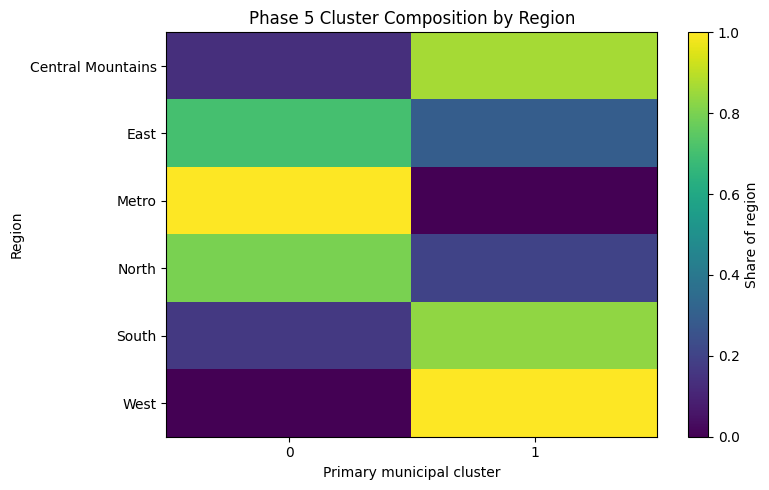

In [9]:
plt.figure(figsize=(8, 5))
plt.imshow(region_cluster_shares.values, aspect="auto")
plt.colorbar(label="Share of region")
plt.xticks(range(region_cluster_shares.shape[1]), region_cluster_shares.columns)
plt.yticks(range(region_cluster_shares.shape[0]), region_cluster_shares.index)
plt.title("Phase 5 Cluster Composition by Region")
plt.xlabel("Primary municipal cluster")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

,mean,median,min,max,count
region,,,,,
Central Mountains,0.748,0.785,0.292,1.000,15
South,0.648,0.656,0.442,1.000,12
West,0.618,0.566,0.281,1.000,16
East,0.473,0.411,0.019,1.000,17
North,0.454,0.462,0.104,0.816,10
Metro,0.118,0.014,0.000,0.425,8


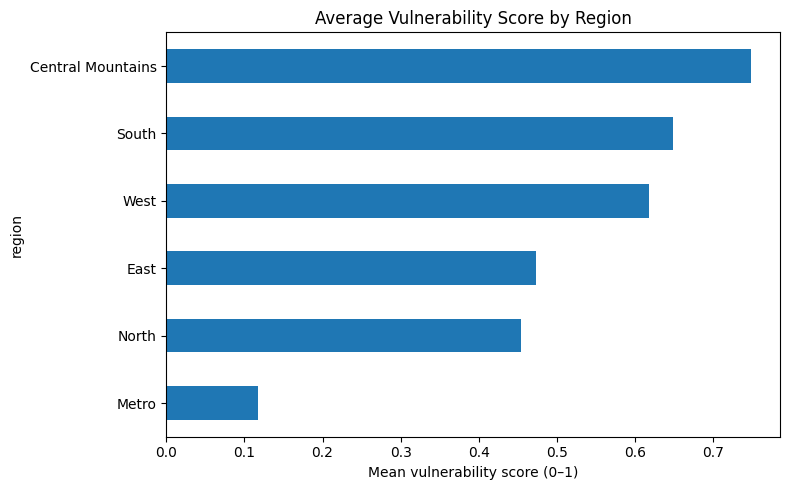

In [10]:
if "vulnerability_score_0_1" in df.columns:
    region_vulnerability = (
        df.groupby("region")["vulnerability_score_0_1"]
        .agg(["mean", "median", "min", "max", "count"])
        .sort_values("mean", ascending=False)
        .round(3)
    )
    display(region_vulnerability)

    plt.figure(figsize=(8, 5))
    region_vulnerability["mean"].sort_values().plot(kind="barh")
    plt.title("Average Vulnerability Score by Region")
    plt.xlabel("Mean vulnerability score (0–1)")
    plt.tight_layout()
    plt.show()
else:
    region_vulnerability = None
    print("No vulnerability_score_0_1 column found in Phase 5 output.")

## 6. Build region-level structural profiles

Each region is summarized using municipal averages and Phase 5 cluster shares.  
These region-level profiles are then used to estimate broader **regional systems**.

The idea is not to replace the geographic regions, but to ask whether the regions themselves fall into a smaller number of similar structural groupings.


In [11]:
profile_metric_candidates = [
    "vulnerability_score_0_1",
    "vulnerability_index",
    "median_income_real",
    "income_growth_pct",
    "target_pop_change",
    "lag_pop_change_1",
    "violent_rate",
    "property_rate",
    "eq_events_365d",
    "max_wind_knots",
]

profile_metric_cols = [c for c in profile_metric_candidates if c in df.columns]

region_profile = (
    df.groupby("region")[profile_metric_cols]
    .mean(numeric_only=True)
    .sort_index()
)

cluster_share_wide = pd.crosstab(df["region"], df[primary_cluster_col], normalize="index")
cluster_share_wide.columns = [f"{primary_cluster_col}_share_{int(c)}" for c in cluster_share_wide.columns]
cluster_share_wide = cluster_share_wide.sort_index()

region_profile = region_profile.join(cluster_share_wide, how="left")

if "typology_label" in df.columns:
    dominant_typology = (
        df.groupby(["region", "typology_label"]).size()
        .reset_index(name="n")
        .sort_values(["region", "n", "typology_label"], ascending=[True, False, True])
        .drop_duplicates("region")
        .set_index("region")["typology_label"]
        .rename("dominant_typology_label")
    )
    region_profile = region_profile.join(dominant_typology, how="left")

region_profile


,vulnerability_score_0_1,vulnerability_index,median_income_real,target_pop_change,lag_pop_change_1,kmeans_cluster_share_0,kmeans_cluster_share_1,dominant_typology_label
region,,,,,,,,
Central Mountains,0.748043,0.429632,23572.914667,-0.342969,-0.241778,0.133333,0.866667,Mixed structural profile
East,0.473188,0.311589,27588.331176,-0.211812,-0.139400,0.705882,0.294118,"Relatively stable, higher-income municipalities"
Metro,0.117877,0.122185,35898.862500,-0.671133,-0.586042,1.000000,0.000000,"Relatively stable, higher-income municipalities"
North,0.453714,0.302364,27019.198000,-0.365375,-0.206062,0.800000,0.200000,"Relatively stable, higher-income municipalities"
South,0.647790,0.385810,24084.488333,-1.175954,-1.072356,0.166667,0.833333,Mixed structural profile
West,0.617930,0.373810,22484.484375,-0.771954,-0.633988,0.000000,1.000000,Mixed structural profile


## 7. Validate region-level systems with clustering diagnostics

Unlike the original version of this notebook, region-level grouping is now **validated explicitly**.

The workflow below:
- standardizes the region-level profile matrix,
- evaluates multiple candidate values of k,
- checks silhouette scores and singleton clusters,
- chooses a **preferred primary region-system solution**, and
- measures seed stability with adjusted Rand index (ARI).

A slightly higher silhouette score is not treated as decisive if it requires a fragmented or singleton structure.


In [12]:
region_cluster_input = region_profile.select_dtypes(include=[np.number]).copy()

constant_region_cols = [
    c for c in region_cluster_input.columns
    if region_cluster_input[c].nunique(dropna=True) <= 1
]
if constant_region_cols:
    region_cluster_input = region_cluster_input.drop(columns=constant_region_cols)

if region_cluster_input.shape[1] == 0:
    raise ValueError("No usable numeric columns remain for region-level clustering.")

scaler = StandardScaler()
X_region = scaler.fit_transform(region_cluster_input)

candidate_ks = list(range(2, min(5, len(region_cluster_input) - 1) + 1))
region_cluster_eval = []

for k in candidate_ks:
    km = KMeans(n_clusters=k, n_init=50, random_state=42)
    labels = km.fit_predict(X_region)
    counts = pd.Series(labels).value_counts().sort_index()
    row = {
        "k": k,
        "inertia": float(km.inertia_),
        "min_cluster_size": int(counts.min()),
        "has_singleton": bool((counts == 1).any()),
    }
    row["silhouette"] = float(silhouette_score(X_region, labels)) if len(set(labels)) > 1 else np.nan
    region_cluster_eval.append(row)

region_cluster_eval = pd.DataFrame(region_cluster_eval).sort_values("k").reset_index(drop=True)
best_sil = region_cluster_eval["silhouette"].max()
preferred_margin = 0.02

eligible = region_cluster_eval[
    (~region_cluster_eval["has_singleton"]) &
    ((best_sil - region_cluster_eval["silhouette"]) <= preferred_margin)
].copy()

if len(eligible) > 0:
    preferred_region_k = int(eligible.sort_values(["k"]).iloc[0]["k"])
else:
    preferred_region_k = int(region_cluster_eval.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]["k"])

best_region_k = int(region_cluster_eval.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]["k"])

region_cluster_eval


,k,inertia,min_cluster_size,has_singleton,silhouette
0,2,16.721859,3,False,0.425414
1,3,7.429943,1,True,0.431857
2,4,2.161435,1,True,0.347315
3,5,0.210065,1,True,0.263682


In [13]:
seed_list = [7, 11, 19, 23, 29, 31, 37, 41, 43, 47]

seed_assignments = {}
for seed in seed_list:
    km = KMeans(n_clusters=preferred_region_k, n_init=50, random_state=seed)
    seed_assignments[seed] = km.fit_predict(X_region)

pairwise_ari = []
seed_keys = list(seed_assignments.keys())
for i in range(len(seed_keys)):
    for j in range(i + 1, len(seed_keys)):
        s1, s2 = seed_keys[i], seed_keys[j]
        pairwise_ari.append({
            "seed_a": s1,
            "seed_b": s2,
            "ari": adjusted_rand_score(seed_assignments[s1], seed_assignments[s2]),
        })

pairwise_ari_df = pd.DataFrame(pairwise_ari)
region_seed_stability = {
    "mean_ari": float(pairwise_ari_df["ari"].mean()) if len(pairwise_ari_df) else np.nan,
    "min_ari": float(pairwise_ari_df["ari"].min()) if len(pairwise_ari_df) else np.nan,
    "max_ari": float(pairwise_ari_df["ari"].max()) if len(pairwise_ari_df) else np.nan,
}

final_region_km = KMeans(n_clusters=preferred_region_k, n_init=100, random_state=42)
region_profile[f"region_system_k{preferred_region_k}"] = final_region_km.fit_predict(X_region)

print("Best silhouette k:", best_region_k)
print("Preferred primary region-system k:", preferred_region_k)
print("Region-system seed stability:", region_seed_stability)

display(pairwise_ari_df.head())
display(region_profile)


Best silhouette k: 3
Preferred primary region-system k: 2
Region-system seed stability: {'mean_ari': 1.0, 'min_ari': 1.0, 'max_ari': 1.0}


,seed_a,seed_b,ari
0,7,11,1.0
1,7,19,1.0
2,7,23,1.0
3,7,29,1.0
4,7,31,1.0


,vulnerability_score_0_1,vulnerability_index,median_income_real,target_pop_change,lag_pop_change_1,kmeans_cluster_share_0,kmeans_cluster_share_1,dominant_typology_label,region_system_k2
region,,,,,,,,,
Central Mountains,0.748043,0.429632,23572.914667,-0.342969,-0.241778,0.133333,0.866667,Mixed structural profile,1
East,0.473188,0.311589,27588.331176,-0.211812,-0.139400,0.705882,0.294118,"Relatively stable, higher-income municipalities",0
Metro,0.117877,0.122185,35898.862500,-0.671133,-0.586042,1.000000,0.000000,"Relatively stable, higher-income municipalities",0
North,0.453714,0.302364,27019.198000,-0.365375,-0.206062,0.800000,0.200000,"Relatively stable, higher-income municipalities",0
South,0.647790,0.385810,24084.488333,-1.175954,-1.072356,0.166667,0.833333,Mixed structural profile,1
West,0.617930,0.373810,22484.484375,-0.771954,-0.633988,0.000000,1.000000,Mixed structural profile,1


## 8. Interpret region systems and map them back to municipalities

The estimated **region systems** are not replacements for the named regions.  
Instead, they provide a compact way to describe which geographic regions appear structurally similar after aggregating municipal vulnerability, income, crime, disaster exposure, and cluster composition.


In [14]:
region_system_col = f"region_system_k{preferred_region_k}"
region_profile["region_system_label"] = (
    "Regional System " + region_profile[region_system_col].astype(int).astype(str)
)

region_system_lookup = region_profile[[region_system_col, "region_system_label"]].copy()
df = df.merge(
    region_system_lookup,
    left_on="region",
    right_index=True,
    how="left"
)

region_system_counts = (
    region_profile.groupby(region_system_col).size().rename("n_regions").to_frame()
)
region_system_counts


,n_regions
region_system_k2,
0,3
1,3


In [15]:
region_summary_cols = [c for c in [
    "vulnerability_score_0_1",
    "median_income_real",
    "target_pop_change_3y_avg",
    "target_pop_change",
    "violent_rate",
    "property_rate",
    "eq_events_365d",
] if c in region_profile.columns]

region_system_profile = (
    region_profile.groupby(region_system_col)[region_summary_cols]
    .mean(numeric_only=True)
    .round(3)
)

region_system_profile


,vulnerability_score_0_1,median_income_real,target_pop_change
region_system_k2,,,
0,0.348,30168.797,-0.416
1,0.671,23380.629,-0.764


## 9. Spatial coherence diagnostics

A regional analysis should not rely only on tabular summaries.  
This section adds a spatial layer:

- it loads municipality boundaries,
- merges the regional and typology outputs back onto geometry,
- computes simple **adjacency-based coherence metrics**, and
- optionally evaluates Moran's I for vulnerability when `libpysal` and `esda` are available.

If the required spatial files or packages are unavailable, the notebook continues without failing.


In [16]:
# --- Spatial dependencies and geometry loading ---
import json
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

HAS_GEO = False
MAP_BACKEND = None
map_gdf = None
map_features = None
geo_path = None

geo_candidates = [
    analysis_dir / "pr_municipalities.geojson",
    analysis_dir / "data" / "pr_municipalities.geojson",
    analysis_dir / ".." / "data" / "tl_2022_72_cousub" / "pr_municipalities.geojson",
    analysis_dir / ".." / "data" / "pr_municipalities.geojson",
]
geo_path = next((p.resolve() for p in geo_candidates if p.exists()), None)

if geo_path is None:
    print("GeoJSON not found. Spatial diagnostics and maps will be skipped.")
else:
    print(f"Geometry candidate found: {geo_path}")
    try:
        import geopandas as gpd
        map_gdf = gpd.read_file(geo_path)
        HAS_GEO = True
        MAP_BACKEND = "geopandas"
        print("Spatial backend: geopandas")
        print("Geometry shape:", map_gdf.shape)
        display(map_gdf.head())
    except ImportError:
        print("geopandas not available in this kernel. Falling back to raw GeoJSON plotting.")
        with open(geo_path, "r", encoding="utf-8") as f:
            geojson_obj = json.load(f)
        map_features = geojson_obj.get("features", [])
        MAP_BACKEND = "geojson_fallback"
        print("Spatial backend: raw GeoJSON fallback")
        print("Feature count:", len(map_features))

def _detect_geo_name_from_properties(props):
    for candidate in ["municipio", "MUNICIPIO", "name", "NAME", "municipality", "Municipality", "NAMELSAD", "county_subdivision"]:
        if candidate in props and props[candidate]:
            return candidate
    return None

def _make_polygon_patches(geometry):
    patches = []
    if not geometry:
        return patches
    gtype = geometry.get("type")
    coords = geometry.get("coordinates", [])
    if gtype == "Polygon":
        polys = [coords]
    elif gtype == "MultiPolygon":
        polys = coords
    else:
        return patches

    for poly in polys:
        if not poly:
            continue
        outer = poly[0]
        if len(outer) >= 3:
            patches.append(MplPolygon(outer, closed=True))
    return patches

def _approx_label_point(geometry):
    if not geometry:
        return None
    pts = []
    gtype = geometry.get("type")
    coords = geometry.get("coordinates", [])
    if gtype == "Polygon":
        polys = [coords]
    elif gtype == "MultiPolygon":
        polys = coords
    else:
        return None
    for poly in polys:
        if poly and poly[0]:
            pts.extend(poly[0])
    if not pts:
        return None
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    return (sum(xs)/len(xs), sum(ys)/len(ys))

def plot_geojson_map(
    feature_df,
    value_col=None,
    categorical=False,
    title="Map",
    cmap="viridis",
    category_colors=None,
    annotate_col=None,
    save_path=None,
    figsize=(12, 8),
):
    if feature_df is None or feature_df.empty:
        print("No fallback geometry available for plotting.")
        return

    fig, ax = plt.subplots(figsize=figsize)
    patches = []
    values = []
    facecolors = []

    for _, row in feature_df.iterrows():
        geom = row.get("geometry")
        row_patches = _make_polygon_patches(geom)
        if not row_patches:
            continue
        patches.extend(row_patches)

        if categorical:
            color = "#d9d9d9"
            if value_col is not None and category_colors is not None:
                color = category_colors.get(row.get(value_col), "#d9d9d9")
            facecolors.extend([color] * len(row_patches))
        else:
            val = row.get(value_col) if value_col is not None else np.nan
            values.extend([val] * len(row_patches))

    if categorical:
        pc = PatchCollection(patches, facecolor=facecolors, edgecolor="white", linewidth=0.4)
        ax.add_collection(pc)
    else:
        pc = PatchCollection(patches, cmap=cmap, edgecolor="white", linewidth=0.4)
        arr = np.array(values, dtype=float) if len(values) else np.array([])
        pc.set_array(arr)
        pc.set_clim(np.nanmin(arr) if len(arr) and np.isfinite(arr).any() else 0,
                    np.nanmax(arr) if len(arr) and np.isfinite(arr).any() else 1)
        ax.add_collection(pc)
        if len(values):
            fig.colorbar(pc, ax=ax, shrink=0.7)

    ax.autoscale()
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=16)

    if annotate_col is not None:
        for _, row in feature_df.iterrows():
            pt = _approx_label_point(row.get("geometry"))
            if pt is None:
                continue
            ax.text(
                pt[0], pt[1], str(row.get(annotate_col, "")),
                fontsize=8, ha="center", va="center", weight="bold",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
            )

    if categorical and category_colors:
        import matplotlib.patches as mpatches
        handles = [mpatches.Patch(color=color, label=str(cat)) for cat, color in category_colors.items()]
        ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(1.01, 0.1), title=value_col)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()


Geometry candidate found: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/data/tl_2022_72_cousub/pr_municipalities.geojson
Spatial backend: geopandas
Geometry shape: (78, 3)


,id,name,geometry
0,0,Añasco,"POLYGON ((-67.18903 18.26622, -67.18903 18.266..."
1,1,Adjuntas,"POLYGON ((-66.79774 18.13365, -66.80194 18.139..."
2,2,Aguada,"POLYGON ((-67.13012 18.31805, -67.13705 18.316..."
3,3,Aguadilla,"POLYGON ((-67.05623 18.46092, -67.07426 18.456..."
4,4,Aguas Buenas,"POLYGON ((-66.16881 18.22423, -66.17622 18.229..."


In [17]:
geo_muni_col = None

if MAP_BACKEND == "geopandas" and map_gdf is not None:
    possible_geo_name_cols = [c for c in map_gdf.columns if c.lower() in {"name", "municipio", "municipality", "namelsad", "county_subdivision"}]
    if not possible_geo_name_cols:
        raise ValueError(
            "Could not detect a municipality name column in the geometry file. "
            "Inspect map_gdf.columns and set geo_muni_col manually."
        )
    geo_muni_col = possible_geo_name_cols[0]
    print("Using geometry municipality column:", geo_muni_col)

    map_gdf["municipio_norm"] = map_gdf[geo_muni_col].map(normalize_name)
    merge_cols = [
        "municipio", "municipio_norm", "region", primary_cluster_col,
        region_system_col, "region_system_label"
    ]
    optional_merge_cols = [
        "typology_label", "vulnerability_score_0_1", "target_pop_change",
        "lag_pop_change_1", "median_income_real"
    ]
    merge_cols += [c for c in optional_merge_cols if c in df.columns and c not in merge_cols]
    map_gdf = map_gdf.merge(df[merge_cols].drop_duplicates("municipio_norm"), on="municipio_norm", how="left")

    print("Merged map shape:", map_gdf.shape)
    print("Rows with missing region after merge:", int(map_gdf["region"].isna().sum()))
    display(map_gdf[[geo_muni_col, "municipio", "region", region_system_col]].head())

elif MAP_BACKEND == "geojson_fallback" and map_features is not None:
    records = []
    for feat in map_features:
        props = feat.get("properties", {}) or {}
        if geo_muni_col is None:
            geo_muni_col = _detect_geo_name_from_properties(props)
        muni_name = props.get(geo_muni_col) if geo_muni_col is not None else None
        records.append({
            "geo_muni_raw": muni_name,
            "municipio_norm": normalize_name(muni_name) if muni_name is not None else None,
            "geometry": feat.get("geometry"),
        })
    map_df = pd.DataFrame(records)
    print("Using fallback geometry municipality column:", geo_muni_col)

    merge_cols = [
        "municipio", "municipio_norm", "region", primary_cluster_col,
        region_system_col, "region_system_label"
    ]
    optional_merge_cols = [
        "typology_label", "vulnerability_score_0_1", "target_pop_change",
        "lag_pop_change_1", "median_income_real"
    ]
    merge_cols += [c for c in optional_merge_cols if c in df.columns and c not in merge_cols]
    map_df = map_df.merge(df[merge_cols].drop_duplicates("municipio_norm"), on="municipio_norm", how="left")

    print("Merged fallback map shape:", map_df.shape)
    print("Rows with missing region after merge:", int(map_df["region"].isna().sum()))
    display(map_df[["geo_muni_raw", "municipio", "region", region_system_col]].head())
else:
    map_df = None
    print("No spatial backend available; all map outputs will be skipped.")


Using geometry municipality column: name
Merged map shape: (78, 14)
Rows with missing region after merge: 0


,name,municipio,region,region_system_k2
0,Añasco,Añasco,West,1
1,Adjuntas,Adjuntas,Central Mountains,1
2,Aguada,Aguada,West,1
3,Aguadilla,Aguadilla,West,1
4,Aguas Buenas,Aguas Buenas,Central Mountains,1


In [18]:
adjacency_summary = None
moran_summary = None

if MAP_BACKEND == "geopandas" and map_gdf is not None:
    work_gdf = map_gdf.dropna(subset=["geometry"]).copy()
    work_gdf = work_gdf.reset_index(drop=True)
    work_gdf["geom_for_adj"] = work_gdf.geometry.buffer(0)

    adjacency_pairs = []
    sindex = work_gdf.sindex

    for i, geom in enumerate(work_gdf["geom_for_adj"]):
        if geom is None or geom.is_empty:
            continue
        candidate_idx = list(sindex.intersection(geom.bounds))
        for j in candidate_idx:
            if j <= i:
                continue
            other = work_gdf.loc[j, "geom_for_adj"]
            if other is None or other.is_empty:
                continue
            if geom.touches(other):
                adjacency_pairs.append({
                    "i": i,
                    "j": j,
                    "same_region": work_gdf.loc[i, "region"] == work_gdf.loc[j, "region"],
                    "same_primary_cluster": work_gdf.loc[i, primary_cluster_col] == work_gdf.loc[j, primary_cluster_col],
                    "same_region_system": work_gdf.loc[i, region_system_col] == work_gdf.loc[j, region_system_col],
                })

    adjacency_pairs_df = pd.DataFrame(adjacency_pairs)

    if not adjacency_pairs_df.empty:
        adjacency_summary = pd.DataFrame({
            "metric": ["share_same_region", "share_same_primary_cluster", "share_same_region_system", "adjacent_pairs"],
            "value": [
                adjacency_pairs_df["same_region"].mean(),
                adjacency_pairs_df["same_primary_cluster"].mean(),
                adjacency_pairs_df["same_region_system"].mean(),
                len(adjacency_pairs_df),
            ],
        })
        display(adjacency_summary)
    else:
        print("No adjacency pairs found in geometry file.")
else:
    print("Adjacency diagnostics skipped because geopandas backend is unavailable.")


,metric,value
0,share_same_region,0.666667
1,share_same_primary_cluster,0.732240
2,share_same_region_system,0.846995
3,adjacent_pairs,183.000000


## 10. Regional profiles and cross-scale interpretation tables


### Interpretation note on region-level averages

Unless otherwise stated, region-level summaries in this notebook are computed as **simple municipal means** rather than population-weighted means. This is useful for comparing the typical structural profile of municipalities within each region, but it is not the same as estimating population-weighted regional conditions.


In [19]:
region_crosswalk = (
    df.groupby(["region", primary_cluster_col]).size()
    .reset_index(name="n")
    .sort_values(["region", "n", primary_cluster_col], ascending=[True, False, True])
)

region_dominant_cluster = (
    region_crosswalk.drop_duplicates("region")
    .set_index("region")[primary_cluster_col]
    .rename("dominant_phase5_cluster")
)

region_profile = region_profile.join(region_dominant_cluster, how="left")
region_profile = region_profile.reset_index()

display(region_profile)
display(region_crosswalk)


,region,vulnerability_score_0_1,vulnerability_index,median_income_real,target_pop_change,lag_pop_change_1,kmeans_cluster_share_0,kmeans_cluster_share_1,dominant_typology_label,region_system_k2,region_system_label,dominant_phase5_cluster
0,Central Mountains,0.748043,0.429632,23572.914667,-0.342969,-0.241778,0.133333,0.866667,Mixed structural profile,1,Regional System 1,1
1,East,0.473188,0.311589,27588.331176,-0.211812,-0.139400,0.705882,0.294118,"Relatively stable, higher-income municipalities",0,Regional System 0,0
2,Metro,0.117877,0.122185,35898.862500,-0.671133,-0.586042,1.000000,0.000000,"Relatively stable, higher-income municipalities",0,Regional System 0,0
3,North,0.453714,0.302364,27019.198000,-0.365375,-0.206062,0.800000,0.200000,"Relatively stable, higher-income municipalities",0,Regional System 0,0
4,South,0.647790,0.385810,24084.488333,-1.175954,-1.072356,0.166667,0.833333,Mixed structural profile,1,Regional System 1,1
5,West,0.617930,0.373810,22484.484375,-0.771954,-0.633988,0.000000,1.000000,Mixed structural profile,1,Regional System 1,1


,region,kmeans_cluster,n
1,Central Mountains,1,13
0,Central Mountains,0,2
2,East,0,12
3,East,1,5
4,Metro,0,8
5,North,0,8
6,North,1,2
8,South,1,10
7,South,0,2
9,West,1,16


In [20]:
top_vulnerable_by_region = None
if "vulnerability_score_0_1" in df.columns:
    top_vulnerable_by_region = (
        df.sort_values(["region", "vulnerability_score_0_1"], ascending=[True, False])
        .groupby("region")
        .head(3)[[
            "region", "municipio", "vulnerability_score_0_1",
            primary_cluster_col, "region_system_label"
        ]]
        .reset_index(drop=True)
    )
    display(top_vulnerable_by_region)
else:
    print("No vulnerability_score_0_1 column found.")


,region,municipio,vulnerability_score_0_1,kmeans_cluster,region_system_label
0,Central Mountains,Adjuntas,1.000000,1,Regional System 1
1,Central Mountains,Comerío,0.999233,1,Regional System 1
2,Central Mountains,Ciales,0.962155,1,Regional System 1
3,East,Vieques,1.000000,0,Regional System 0
4,East,Maunabo,0.959500,1,Regional System 0
5,East,Yabucoa,0.728193,1,Regional System 0
6,Metro,Cataño,0.424877,0,Regional System 0
7,Metro,Toa Alta,0.286706,0,Regional System 0
8,Metro,Toa Baja,0.202846,0,Regional System 0
9,North,Florida,0.816250,1,Regional System 0


## 11. Static maps and regional choropleths


Saved: phase6_map_regions.png


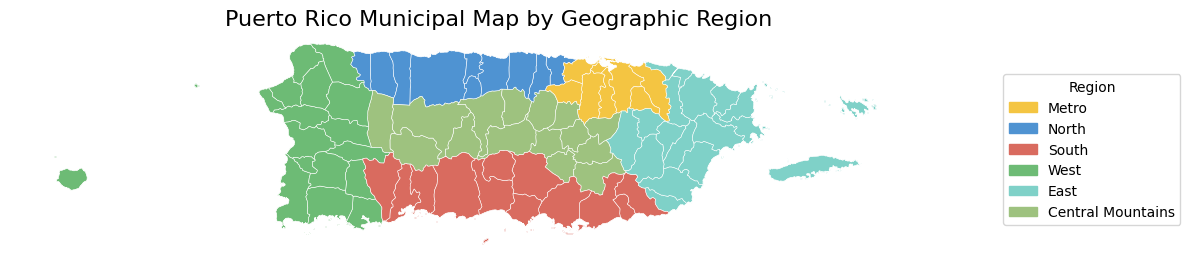

In [21]:
region_map_png = analysis_dir / "phase6_map_regions.png"

region_colors = {
    "Metro": "#f4c542",
    "North": "#4f93d2",
    "South": "#d96b5f",
    "West": "#6dbb75",
    "East": "#7fd1c8",
    "Central Mountains": "#9ec27f",
}

if MAP_BACKEND == "geopandas" and map_gdf is not None:
    map_gdf["region_color"] = map_gdf["region"].map(region_colors)

    fig, ax = plt.subplots(figsize=(12, 8))
    map_gdf.plot(
        ax=ax,
        color=map_gdf["region_color"].fillna("#d9d9d9"),
        edgecolor="white",
        linewidth=0.4,
    )
    ax.set_title("Puerto Rico Municipal Map by Geographic Region", fontsize=16)
    ax.axis("off")

    import matplotlib.patches as mpatches
    handles = [mpatches.Patch(color=color, label=region) for region, color in region_colors.items()]
    ax.legend(handles=handles, title="Region", loc="lower left", bbox_to_anchor=(1.01, 0.1))
    plt.tight_layout()
    plt.savefig(region_map_png, dpi=200, bbox_inches="tight")
    print(f"Saved: {region_map_png}")
    plt.show()
elif MAP_BACKEND == "geojson_fallback" and map_df is not None:
    plot_geojson_map(
        map_df,
        value_col="region",
        categorical=True,
        category_colors=region_colors,
        title="Puerto Rico Municipal Map by Geographic Region",
        save_path=region_map_png,
    )
else:
    print("Region map skipped because no spatial backend is available.")


Saved: phase6_map_region_systems.png


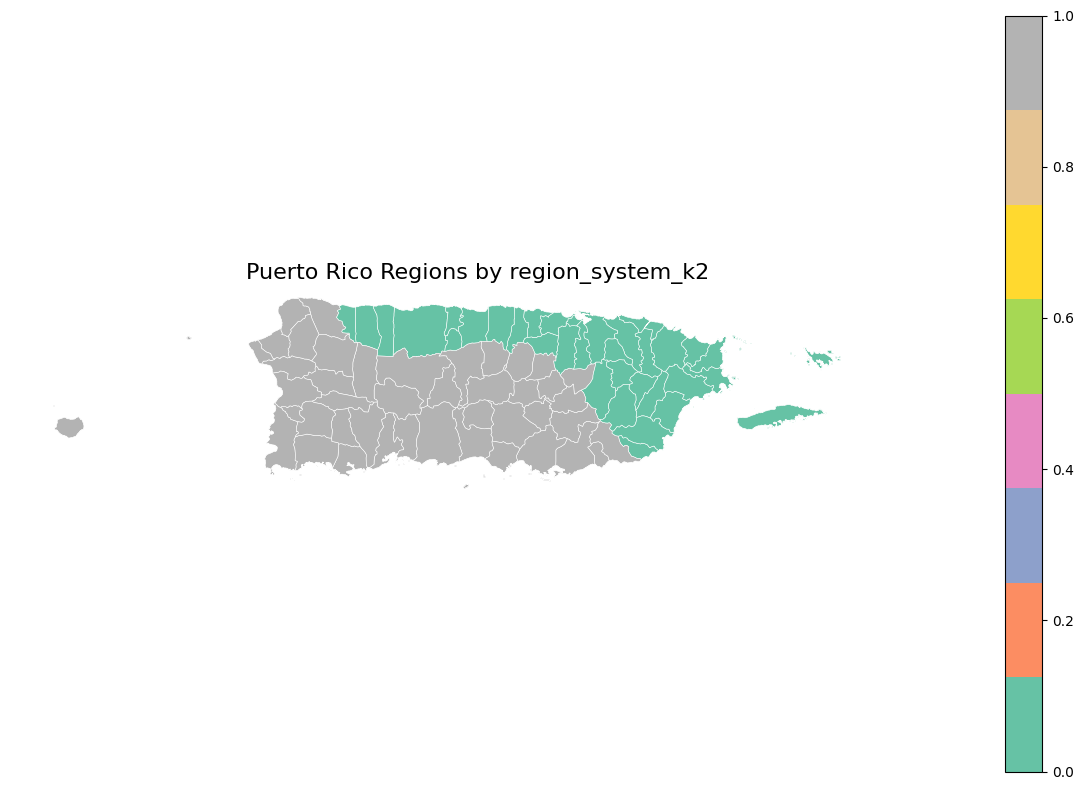

In [22]:
region_system_map_png = analysis_dir / "phase6_map_region_systems.png"

if MAP_BACKEND == "geopandas" and map_gdf is not None:
    fig, ax = plt.subplots(figsize=(12, 8))
    map_gdf.plot(
        column=region_system_col,
        cmap="Set2",
        linewidth=0.4,
        edgecolor="white",
        legend=True,
        ax=ax,
        missing_kwds={"color": "#d9d9d9", "label": "Missing"},
    )
    ax.set_title(f"Puerto Rico Regions by {region_system_col}", fontsize=16)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(region_system_map_png, dpi=200, bbox_inches="tight")
    print(f"Saved: {region_system_map_png}")
    plt.show()
elif MAP_BACKEND == "geojson_fallback" and map_df is not None:
    cats = sorted([x for x in map_df[region_system_col].dropna().unique()])
    palette = plt.cm.Set2(np.linspace(0, 1, max(len(cats), 1)))
    from matplotlib import colors as mcolors
    category_colors = {cat: mcolors.to_hex(palette[i]) for i, cat in enumerate(cats)}
    plot_geojson_map(
        map_df,
        value_col=region_system_col,
        categorical=True,
        category_colors=category_colors,
        title=f"Puerto Rico Regions by {region_system_col}",
        save_path=region_system_map_png,
    )
else:
    print("Region-system map skipped because no spatial backend is available.")


Saved: phase6_map_vulnerability.png


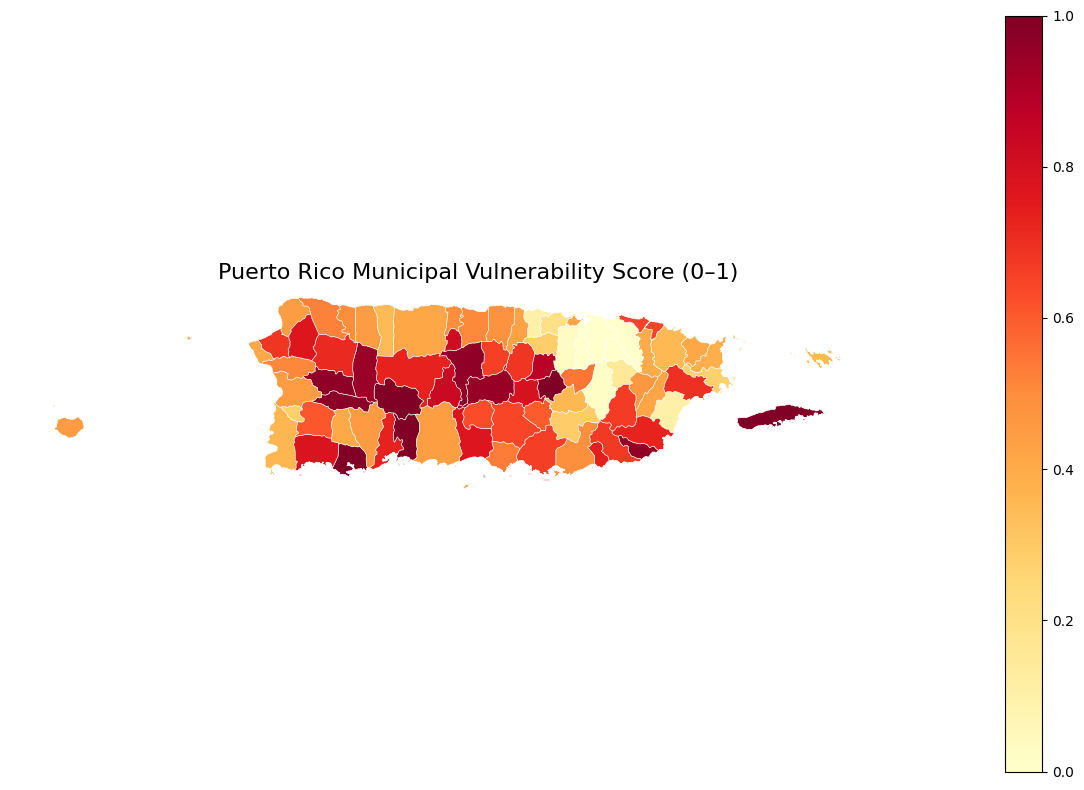

In [23]:
vulnerability_map_png = analysis_dir / "phase6_map_vulnerability.png"

if MAP_BACKEND == "geopandas" and map_gdf is not None and "vulnerability_score_0_1" in map_gdf.columns:
    fig, ax = plt.subplots(figsize=(12, 8))
    map_gdf.plot(
        column="vulnerability_score_0_1",
        cmap="YlOrRd",
        linewidth=0.4,
        edgecolor="white",
        legend=True,
        ax=ax,
        missing_kwds={"color": "#d9d9d9", "label": "Missing"},
    )
    ax.set_title("Puerto Rico Municipal Vulnerability Score (0–1)", fontsize=16)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(vulnerability_map_png, dpi=200, bbox_inches="tight")
    print(f"Saved: {vulnerability_map_png}")
    plt.show()
elif MAP_BACKEND == "geojson_fallback" and map_df is not None and "vulnerability_score_0_1" in map_df.columns:
    plot_geojson_map(
        map_df,
        value_col="vulnerability_score_0_1",
        categorical=False,
        cmap="YlOrRd",
        title="Puerto Rico Municipal Vulnerability Score (0–1)",
        save_path=vulnerability_map_png,
    )
else:
    print("Vulnerability map skipped because spatial or vulnerability data are unavailable.")


Saved: phase6_map_regions_labeled.png


/var/folders/05/ctjbc6n50_xcbslxp158gts40000gn/T/ipykernel_35307/2766568219.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  region_centroids = map_gdf.dissolve(by="region").centroid


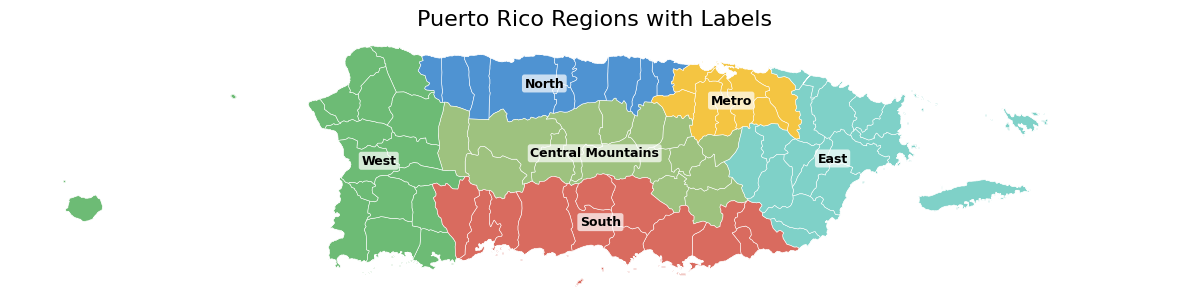

In [24]:
labeled_region_map_png = analysis_dir / "phase6_map_regions_labeled.png"

if MAP_BACKEND == "geopandas" and map_gdf is not None:
    region_centroids = map_gdf.dissolve(by="region").centroid

    fig, ax = plt.subplots(figsize=(12, 8))
    map_gdf.plot(
        ax=ax,
        color=map_gdf["region_color"].fillna("#d9d9d9") if "region_color" in map_gdf.columns else "#d9d9d9",
        edgecolor="white",
        linewidth=0.4,
    )

    for region, point in region_centroids.items():
        if point is not None and not point.is_empty:
            ax.text(
                point.x,
                point.y,
                region,
                fontsize=9,
                ha="center",
                va="center",
                weight="bold",
                color="black",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
            )

    ax.set_title("Puerto Rico Regions with Labels", fontsize=16)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(labeled_region_map_png, dpi=200, bbox_inches="tight")
    print(f"Saved: {labeled_region_map_png}")
    plt.show()
elif MAP_BACKEND == "geojson_fallback" and map_df is not None:
    plot_geojson_map(
        map_df,
        value_col="region",
        categorical=True,
        category_colors=region_colors,
        annotate_col="region",
        title="Puerto Rico Regions with Labels",
        save_path=labeled_region_map_png,
    )
else:
    print("Labeled region map skipped because no spatial backend is available.")


### Regional population change maps

These maps restore the region-level population change views from the original notebook while keeping the improved Phase 6 regional workflow.  
They summarize average municipal population change by region and annotate each region with its mean value.


Using population-change column for regional maps: target_pop_change


,region,target_pop_change,vulnerability_score_0_1
0,Central Mountains,-0.342969,0.748043
1,East,-0.211812,0.473188
2,Metro,-0.671133,0.117877
3,North,-0.365375,0.453714
4,South,-1.175954,0.647790
5,West,-0.771954,0.617930


Saved: phase6_map_region_pop_change.png


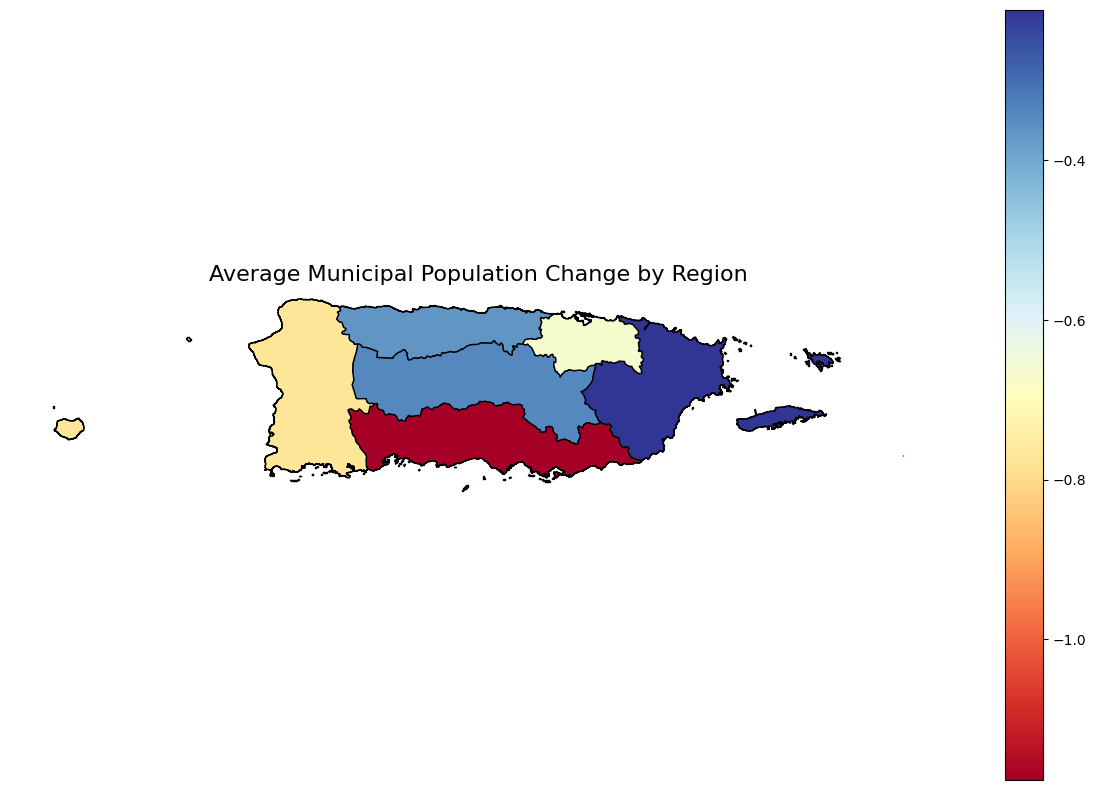

Saved: phase6_map_region_pop_change_labeled.png


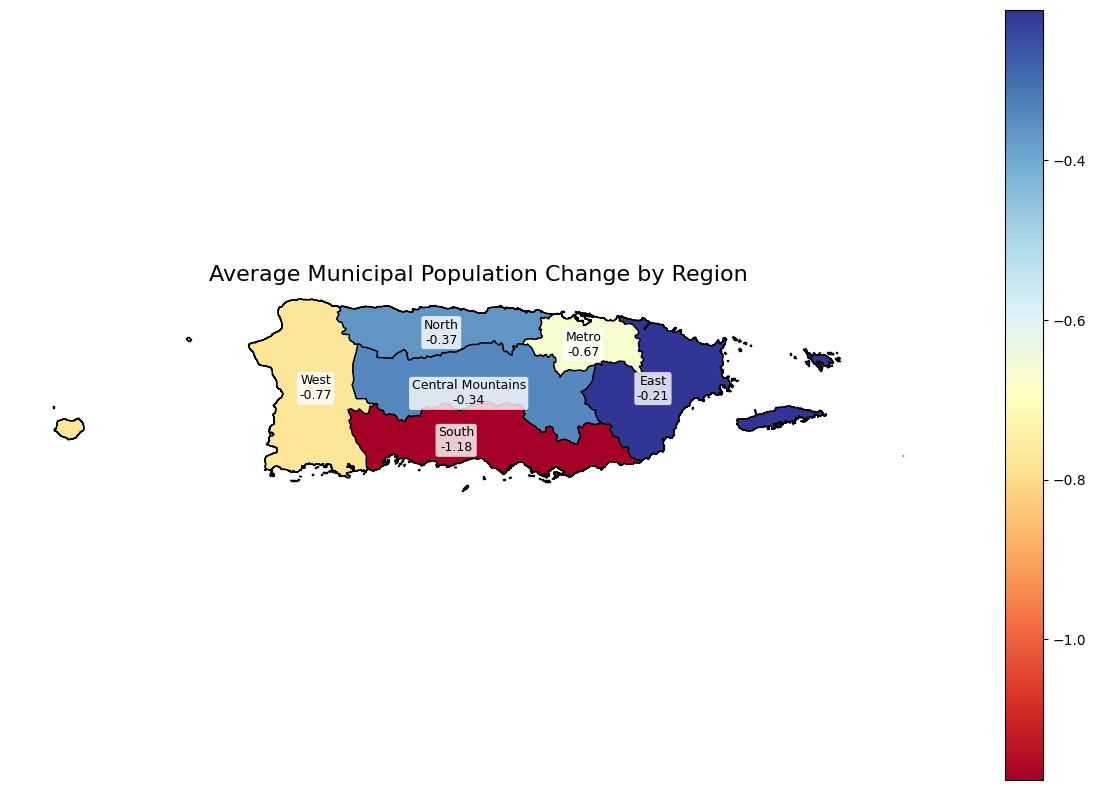

,region,target_pop_change,vulnerability_score_0_1
4,South,-1.175954,0.647790
5,West,-0.771954,0.617930
2,Metro,-0.671133,0.117877
3,North,-0.365375,0.453714
0,Central Mountains,-0.342969,0.748043
1,East,-0.211812,0.473188


In [25]:
region_loss_gdf = None
region_loss_summary = None
region_pop_change_map_png = analysis_dir / "phase6_map_region_pop_change.png"
region_pop_change_labeled_png = analysis_dir / "phase6_map_region_pop_change_labeled.png"

# Prefer the original target column, but fall back gracefully if the latest-year export
# only carries a recent population-change proxy.
pop_change_col = None
for candidate in ["target_pop_change_3y_avg", "target_pop_change", "lag_pop_change_1", "lag_pop_change_2"]:
    if MAP_BACKEND == "geopandas" and map_gdf is not None and candidate in map_gdf.columns:
        pop_change_col = candidate
        break
    if MAP_BACKEND == "geojson_fallback" and map_df is not None and candidate in map_df.columns:
        pop_change_col = candidate
        break

if pop_change_col is None:
    print("No population-change column available in merged Phase 6 map data. Regional population-change maps will be skipped.")
else:
    print(f"Using population-change column for regional maps: {pop_change_col}")

if pop_change_col is not None and MAP_BACKEND == "geopandas" and map_gdf is not None:
    agg_map = {pop_change_col: "mean"}
    if "vulnerability_score_0_1" in map_gdf.columns:
        agg_map["vulnerability_score_0_1"] = "mean"

    region_loss_gdf = map_gdf.dissolve(by="region", aggfunc=agg_map).reset_index()

    keep_cols = ["region", pop_change_col]
    if "vulnerability_score_0_1" in region_loss_gdf.columns:
        keep_cols.append("vulnerability_score_0_1")
    display(region_loss_gdf[keep_cols])

    # Map 1: average municipal population change by region
    fig, ax = plt.subplots(figsize=(12, 8))
    region_loss_gdf.plot(
        column=pop_change_col,
        cmap="RdYlBu",
        linewidth=1.0,
        edgecolor="black",
        legend=True,
        ax=ax,
        missing_kwds={"color": "#d9d9d9", "label": "Missing"},
    )
    ax.set_title("Average Municipal Population Change by Region", fontsize=16)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(region_pop_change_map_png, dpi=200, bbox_inches="tight")
    print(f"Saved: {region_pop_change_map_png}")
    plt.show()

    # Map 2: same regional map with region names and values
    fig, ax = plt.subplots(figsize=(12, 8))
    region_loss_gdf.plot(
        column=pop_change_col,
        cmap="RdYlBu",
        linewidth=1.0,
        edgecolor="black",
        legend=True,
        ax=ax,
        missing_kwds={"color": "#d9d9d9", "label": "Missing"},
    )

    label_points = region_loss_gdf.geometry.representative_point()
    for (_, row), pt in zip(region_loss_gdf.iterrows(), label_points):
        if pt is not None and not pt.is_empty:
            ax.text(
                pt.x,
                pt.y,
                f"{row['region']}\n{row[pop_change_col]:.2f}",
                fontsize=9,
                ha="center",
                va="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
            )

    ax.set_title("Average Municipal Population Change by Region", fontsize=16)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(region_pop_change_labeled_png, dpi=200, bbox_inches="tight")
    print(f"Saved: {region_pop_change_labeled_png}")
    plt.show()

    region_loss_summary = region_loss_gdf[keep_cols].sort_values(pop_change_col)
    display(region_loss_summary)

elif pop_change_col is not None and MAP_BACKEND == "geojson_fallback" and map_df is not None:
    agg_dict = {pop_change_col: "mean"}
    if "vulnerability_score_0_1" in map_df.columns:
        agg_dict["vulnerability_score_0_1"] = "mean"

    region_loss_summary = (
        map_df.groupby("region", dropna=False)
        .agg(agg_dict)
        .reset_index()
        .sort_values(pop_change_col)
    )
    display(region_loss_summary)

    # Fallback map 1: municipality-level choropleth using the same population-change field
    plot_geojson_map(
        map_df,
        value_col=pop_change_col,
        categorical=False,
        cmap="RdYlBu",
        title="Average Municipal Population Change by Region",
        save_path=region_pop_change_map_png,
    )

    # Fallback map 2: municipality-level choropleth with region labels
    plot_geojson_map(
        map_df,
        value_col=pop_change_col,
        categorical=False,
        cmap="RdYlBu",
        annotate_col="region",
        title="Average Municipal Population Change by Region",
        save_path=region_pop_change_labeled_png,
    )
else:
    print("Population change maps skipped because spatial or population-change data are unavailable.")


## 12. Export Phase 6 outputs

The notebook exports both municipality-level and region-level outputs so the results can feed directly into the dashboard, profile pages, or paper tables.


In [26]:
region_profile_out = analysis_dir / "phase6_region_profiles.csv"
region_cluster_counts_out = analysis_dir / "phase6_region_cluster_counts.csv"
region_cluster_shares_out = analysis_dir / "phase6_region_cluster_shares.csv"
region_system_profile_out = analysis_dir / "phase6_region_system_profiles.csv"
region_eval_out = analysis_dir / "phase6_region_system_diagnostics.csv"
region_crosswalk_out = analysis_dir / "phase6_region_phase5_crosswalk.csv"
region_dominance_out = analysis_dir / "phase6_region_dominance.csv"
summary_out = analysis_dir / "phase6_regional_summary.json"

region_profile.to_csv(region_profile_out, index=False)
region_cluster_counts.to_csv(region_cluster_counts_out)
region_cluster_shares.to_csv(region_cluster_shares_out)
region_system_profile.to_csv(region_system_profile_out)
region_cluster_eval.to_csv(region_eval_out, index=False)
region_crosswalk.to_csv(region_crosswalk_out, index=False)
if "region_dominance" in globals() and region_dominance is not None:
    region_dominance.to_csv(region_dominance_out, index=False)

if top_vulnerable_by_region is not None:
    top_vulnerable_by_region.to_csv(analysis_dir / "phase6_top_vulnerable_by_region.csv", index=False)

map_out = None
if MAP_BACKEND == "geopandas" and map_gdf is not None:
    map_out = analysis_dir / "phase6_regional_map.geojson"
    map_gdf.to_file(map_out, driver="GeoJSON")
    print(f"Saved: {map_out}")

if region_loss_summary is not None:
    region_loss_summary.to_csv(analysis_dir / "phase6_region_population_change_summary.csv", index=False)

map_outputs = {}
for name in [
    "region_map_png",
    "region_system_map_png",
    "vulnerability_map_png",
    "labeled_region_map_png",
    "region_pop_change_map_png",
    "region_pop_change_labeled_png",
]:
    p = globals().get(name)
    if p is not None:
        map_outputs[name] = str(p)

phase6_summary = {
    "phase5_typology_file": typology_path.name,
    "primary_phase5_cluster_column": primary_cluster_col,
    "detected_phase5_cluster_columns": cluster_cols,
    "missing_region_mappings": missing_region,
    "region_counts": region_counts.to_dict(),
    "profile_metric_cols": profile_metric_cols,
    "spatial_backend": MAP_BACKEND,
    "has_geopandas": bool(HAS_GEO),
    "geometry_file_used": str(geo_path) if geo_path is not None else None,
    "constant_region_cols_removed": constant_region_cols,
    "best_region_system_k_by_silhouette": best_region_k,
    "preferred_primary_region_system_k": preferred_region_k,
    "region_system_seed_stability": region_seed_stability,
    "adjacency_summary": adjacency_summary.to_dict(orient="records") if hasattr(adjacency_summary, "to_dict") else adjacency_summary,
    "moran_summary": moran_summary,
    "map_outputs": map_outputs,
    "regional_geojson_output": str(map_out) if map_out is not None else None,
}

with open(summary_out, "w") as f:
    json.dump(phase6_summary, f, indent=4)

print(f"Saved: {region_profile_out}")
print(f"Saved: {region_cluster_counts_out}")
print(f"Saved: {region_cluster_shares_out}")
print(f"Saved: {region_system_profile_out}")
print(f"Saved: {region_eval_out}")
print(f"Saved: {region_crosswalk_out}")
print(f"Saved: {summary_out}")
if map_outputs:
    print("Saved map images:")
    for k, v in map_outputs.items():
        print(f"  - {k}: {v}")


Saved: phase6_regional_map.geojson
Saved: phase6_region_profiles.csv
Saved: phase6_region_cluster_counts.csv
Saved: phase6_region_cluster_shares.csv
Saved: phase6_region_system_profiles.csv
Saved: phase6_region_system_diagnostics.csv
Saved: phase6_region_phase5_crosswalk.csv
Saved: phase6_regional_summary.json
Saved map images:
  - region_map_png: phase6_map_regions.png
  - region_system_map_png: phase6_map_region_systems.png
  - vulnerability_map_png: phase6_map_vulnerability.png
  - labeled_region_map_png: phase6_map_regions_labeled.png
  - region_pop_change_map_png: phase6_map_region_pop_change.png
  - region_pop_change_labeled_png: phase6_map_region_pop_change_labeled.png


## Island-Level Population Dynamics

This section complements the municipio- and region-level analysis by summarizing population change for **Puerto Rico as a whole**. It is designed to quantify the overall scale of population decline using the best available population-change field in the merged Phase 6 municipality table.

The summary below should be interpreted alongside the region-level maps and tables:

- If a population level column is available, the notebook computes a **population-weighted island-wide average change**.
- If a population level column is not available, the notebook falls back to a **simple municipal average** of the selected population-change field.
- This island-level aggregation does not replace the regional analysis; instead, it provides a statewide benchmark against which municipal and regional patterns can be interpreted.


In [27]:
# --- Island-level population dynamics summary ---
from pathlib import Path
import json
import pandas as pd
import numpy as np

def _normalize_municipio_name(s):
    return (
        str(s)
        .upper()
        .strip()
        .replace(" MUNICIPIO", "")
    )

island_df = df.copy()

# Try to augment with population and population-change fields from the processed Phase 2 panel
processed_candidates = [
    analysis_dir / ".." / "data" / "processed_puerto_rico_data.csv",
    analysis_dir / "processed_puerto_rico_data.csv",
    analysis_dir / ".." / "analysis" / "processed_puerto_rico_data.csv",
]
processed_path = next((p for p in processed_candidates if p.exists()), None)

if "municipio" in island_df.columns:
    island_df["mun_key"] = island_df["municipio"].map(_normalize_municipio_name)

if processed_path is not None:
    processed_df = pd.read_csv(processed_path)
    if "municipio" in processed_df.columns and "year" in processed_df.columns:
        processed_df = processed_df.sort_values(["municipio", "year"]).reset_index(drop=True)
        processed_df["mun_key"] = processed_df["municipio"].map(_normalize_municipio_name)

        # Rebuild forward-average target if needed
        if "target_pop_change_3y_avg" not in processed_df.columns and "target_pop_change" in processed_df.columns:
            grp = processed_df.groupby("mun_key")["target_pop_change"]
            processed_df["target_pop_change_3y_avg"] = (
                grp.shift(-1) + grp.shift(-2) + grp.shift(-3)
            ) / 3.0

        # Use the latest year available in the Phase 6 municipality table when possible
        latest_year_value = int(island_df["year"].max()) if "year" in island_df.columns else int(processed_df["year"].max())
        panel_latest = processed_df[processed_df["year"] == latest_year_value].copy()

        merge_cols = [
            c for c in [
                "mun_key",
                "population",
                "population_level",
                "pop",
                "total_population",
                "target_pop_change_3y_avg",
                "target_pop_change",
                "lag_pop_change_1",
                "lag_pop_change_2",
            ]
            if c in panel_latest.columns
        ]

        if "mun_key" in island_df.columns and len(merge_cols) > 1:
            island_df = island_df.merge(panel_latest[merge_cols], on="mun_key", how="left", suffixes=("", "_panel"))

            for c in ["population", "population_level", "pop", "total_population",
                      "target_pop_change_3y_avg", "target_pop_change", "lag_pop_change_1", "lag_pop_change_2"]:
                panel_c = f"{c}_panel"
                if panel_c in island_df.columns:
                    if c not in island_df.columns:
                        island_df[c] = island_df[panel_c]
                    else:
                        island_df[c] = island_df[c].where(island_df[c].notna(), island_df[panel_c])
                    island_df.drop(columns=[panel_c], inplace=True)

            print(f"Augmented island summary inputs from: {processed_path}")
    else:
        print(f"Processed panel found at {processed_path}, but municipio/year columns were unavailable.")
else:
    print("No processed Phase 2 panel found for island summary augmentation.")

island_summary = {}

# Choose the best available population-change column with actual non-null values
island_pop_change_col = None
for candidate in ["target_pop_change_3y_avg", "target_pop_change", "lag_pop_change_1", "lag_pop_change_2"]:
    if candidate in island_df.columns and island_df[candidate].notna().any():
        island_pop_change_col = candidate
        break

# Choose the best available population-level column with actual non-null values
population_level_col = None
for candidate in ["population", "population_level", "pop", "total_population"]:
    if candidate in island_df.columns and island_df[candidate].notna().any():
        population_level_col = candidate
        break

if island_pop_change_col is None:
    print("No usable population-change column available for island-level summary.")
else:
    island_summary["population_change_column_used"] = island_pop_change_col
    island_summary["population_change_units"] = "percent"
    island_summary["n_municipios"] = int(len(island_df))
    island_summary["non_null_population_change_rows"] = int(island_df[island_pop_change_col].notna().sum())
    island_summary["simple_municipal_avg_change_pct"] = float(island_df[island_pop_change_col].dropna().mean())

    if population_level_col is not None:
        valid_island = island_df[[population_level_col, island_pop_change_col]].dropna().copy()
        valid_island = valid_island[valid_island[population_level_col] != 0].copy()
        island_summary["population_level_column_used"] = population_level_col
        island_summary["non_null_population_rows"] = int(valid_island.shape[0])

        if not valid_island.empty and valid_island[population_level_col].sum() != 0:
            total_pop = float(valid_island[population_level_col].sum())
            weighted_avg_pct = float(
                (valid_island[population_level_col] * valid_island[island_pop_change_col]).sum()
                / valid_island[population_level_col].sum()
            )

            island_summary["total_population"] = total_pop
            island_summary["population_weighted_avg_change_pct"] = weighted_avg_pct
            island_summary["total_population_loss"] = float(total_pop * (weighted_avg_pct / 100.0))
            island_summary["population_loss_note"] = (
                "total_population_loss is computed as total_population * "
                "(population_weighted_avg_change_pct / 100), assuming the change field is stored in percent units."
            )

            # Bootstrap percentile estimates for island-level change and total loss
            rng = np.random.default_rng(42)
            n_boot = 2000
            weighted_draws_pct = []

            weights = valid_island[population_level_col].to_numpy(dtype=float)
            changes = valid_island[island_pop_change_col].to_numpy(dtype=float)
            n = len(valid_island)

            for _ in range(n_boot):
                idx = rng.integers(0, n, size=n)
                w = weights[idx]
                c = changes[idx]
                denom = w.sum()
                if denom > 0:
                    weighted_draws_pct.append(float((w * c).sum() / denom))

            if weighted_draws_pct:
                weighted_draws_pct = np.array(weighted_draws_pct, dtype=float)
                island_summary["population_weighted_avg_change_pct_p5"] = float(np.percentile(weighted_draws_pct, 5))
                island_summary["population_weighted_avg_change_pct_p50"] = float(np.percentile(weighted_draws_pct, 50))
                island_summary["population_weighted_avg_change_pct_p95"] = float(np.percentile(weighted_draws_pct, 95))

                total_loss_draws = total_pop * (weighted_draws_pct / 100.0)
                island_summary["total_population_loss_p5"] = float(np.percentile(total_loss_draws, 5))
                island_summary["total_population_loss_p50"] = float(np.percentile(total_loss_draws, 50))
                island_summary["total_population_loss_p95"] = float(np.percentile(total_loss_draws, 95))
                island_summary["uncertainty_note"] = (
                    "Percentile fields are bootstrap percentile estimates (P5/P50/P95) based on resampling municipios. "
                    "They are empirical uncertainty summaries, not formal model predictive quantiles."
                )
        else:
            print("No usable population-level column available; reporting simple municipal average only.")
    else:
        print("No usable population-level column available; reporting simple municipal average only.")

    island_summary_df = pd.DataFrame([island_summary])
    display(island_summary_df)

    island_summary_out = analysis_dir / "phase6_island_population_summary.csv"
    island_summary_df.to_csv(island_summary_out, index=False)
    print(f"Saved island-level population summary to: {island_summary_out}")

    island_summary_json_out = analysis_dir / "phase6_island_population_summary.json"
    with open(island_summary_json_out, "w") as f:
        json.dump(island_summary, f, indent=2)
    print(f"Saved island-level population summary JSON to: {island_summary_json_out}")


Augmented island summary inputs from: ../data/processed_puerto_rico_data.csv


,population_change_column_used,population_change_units,n_municipios,non_null_population_change_rows,simple_municipal_avg_change_pct,population_level_column_used,non_null_population_rows,total_population,population_weighted_avg_change_pct,total_population_loss,population_loss_note,population_weighted_avg_change_pct_p5,population_weighted_avg_change_pct_p50,population_weighted_avg_change_pct_p95,total_population_loss_p5,total_population_loss_p50,total_population_loss_p95,uncertainty_note
0,target_pop_change,percent,78,78,-0.567063,total_population,78,3234309.0,-0.629486,-20359.536551,total_population_loss is computed as total_pop...,-0.729541,-0.628899,-0.531002,-23595.599658,-20340.551304,-17174.233777,Percentile fields are bootstrap percentile est...


Saved island-level population summary to: phase6_island_population_summary.csv
Saved island-level population summary JSON to: phase6_island_population_summary.json


# Phase 6 Conclusion: Regional Systems, Spatial Coherence, and Cross-Scale Structure

Phase 6 serves as the **regional synthesis layer** of the project, translating the municipal-level structural typologies from Phase 5 into a coherent spatial and cross-scale framework. Rather than redefining clusters at a higher aggregation level, this phase explicitly preserves the preferred municipal clustering solution and asks a more meaningful question: **how do these local structural conditions organize across space and aggregate to island-wide outcomes?**

A key strength of this phase is the clear separation between **geographic regions**, **data-driven regional systems**, and **island-level summaries**. Geographic regions are defined exogenously through a fixed municipality-to-region mapping, ensuring interpretability and consistency. Regional systems, by contrast, emerge endogenously from the distribution of municipal characteristics within those regions, providing **higher-order structural groupings**. Finally, island-level metrics aggregate these patterns into a single summary of population change, allowing for a fully integrated multi-scale perspective.

The results demonstrate that Puerto Rico exhibits a **high degree of spatial coherence in its structural patterns**. Adjacent municipalities frequently share similar vulnerability profiles, typology assignments, and regional system classifications. High agreement rates across neighboring units, combined with perfect seed stability in the regional system clustering, indicate that the observed structure is not an artifact of model specification but reflects **genuine spatial organization in the data**.

Substantively, the regional profiles reveal a clear and policy-relevant gradient. The southern region emerges as the most structurally vulnerable and demographically declining area, while eastern and northern regions exhibit comparatively lower rates of decline. The central mountainous region occupies an intermediate position, reflecting both geographic isolation and structural constraints. These patterns are consistent with broader economic and environmental narratives, reinforcing that **population change is not spatially random but closely tied to persistent structural inequalities**.

Importantly, this phase extends beyond regional description by incorporating an **island-wide population change estimate with uncertainty**. Using population-weighted aggregation, the results indicate an overall annual population decline of approximately **−0.6%**, corresponding to a loss of roughly **20,000 residents per year**. Bootstrap percentile estimates further show that this decline is **stable and tightly bounded**, with plausible values falling within a narrow range. These uncertainty estimates should be interpreted as **empirical variability across municipios**, rather than formal predictive intervals, but they provide a useful measure of robustness in the aggregate signal.

This cross-scale consistency is a central contribution of the project. Municipal typologies (Phase 5), regional systems (Phase 6), and island-level summaries all align to tell a coherent story: **Puerto Rico’s population decline is systematic, spatially structured, and driven by persistent structural conditions rather than isolated local shocks**.

At the same time, the results should be interpreted with appropriate caution. Regional summaries are based on **municipal averages rather than population-weighted measures**, meaning they describe the typical municipio rather than the experience of the average resident. Similarly, the island-level uncertainty estimates reflect **sampling variability**, not causal or predictive uncertainty. As such, Phase 6 should be understood as a **descriptive, structural, and organizational layer**, not a causal framework.

In combination with the earlier phases, this final step completes a unified analytical pipeline:

- Phase 2 establishes the limits of predictive modeling,
- Phase 4 clarifies what the models learn,
- Phase 5 identifies stable municipal typologies, and
- Phase 6 organizes those typologies into coherent regional systems and aggregates them to the island level.

Together, these results demonstrate that Puerto Rico’s population dynamics are best understood as a **multi-scale spatial system**, where local structural conditions, regional organization, and island-wide outcomes are tightly interconnected. Even in the absence of strong predictive performance, the project shows that it is possible to recover **stable, interpretable, and policy-relevant structure** across all levels of analysis.

/var/folders/05/ctjbc6n50_xcbslxp158gts40000gn/T/ipykernel_35307/3017207031.py:76: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,year,total_population,weighted_avg_change_pct,simple_avg_change_pct,n_municipios
0,2013,3682966.0,-0.904200,-0.792299,78.0
1,2014,3638965.0,-1.190452,-0.963268,78.0
2,2015,3583073.0,-1.531717,-1.392229,78.0
3,2016,3529385.0,-1.494431,-1.379121,78.0
4,2017,3468963.0,-1.708216,-1.574415,78.0
5,2018,3386941.0,-2.359980,-2.320414,78.0
6,2019,3318447.0,-2.018168,-1.884846,78.0
7,2020,3255642.0,-1.888225,-1.702622,78.0
8,2021,3311274.0,1.928693,0.745949,78.0
9,2022,3272382.0,-1.170972,-1.291867,78.0


Saved: phase6_island_year_summary.csv
Saved: phase6_island_year_summary.json


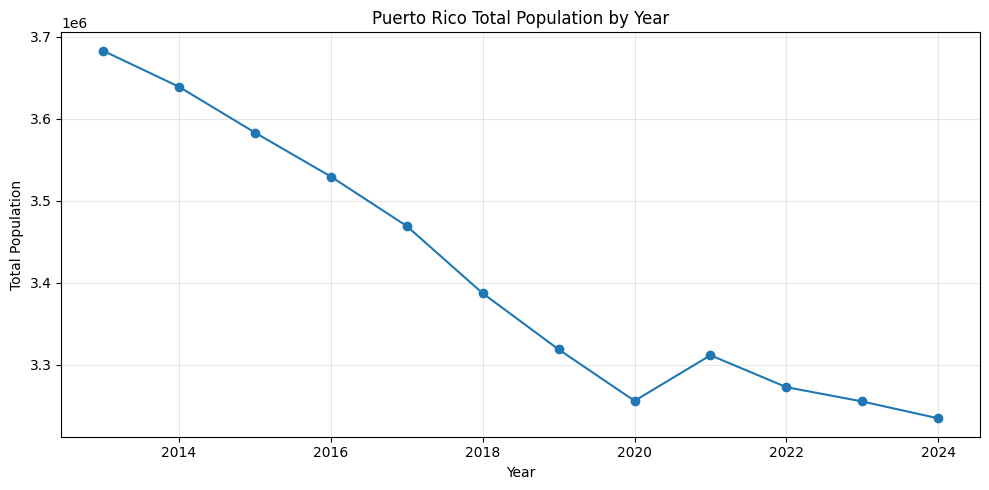

Saved: phase6_island_population_trend.png


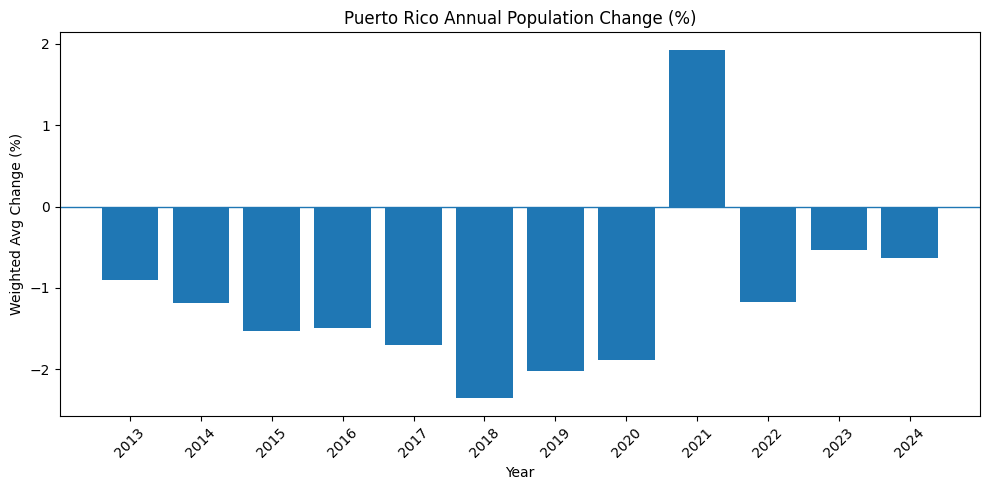

Saved: phase6_island_annual_change_bar.png


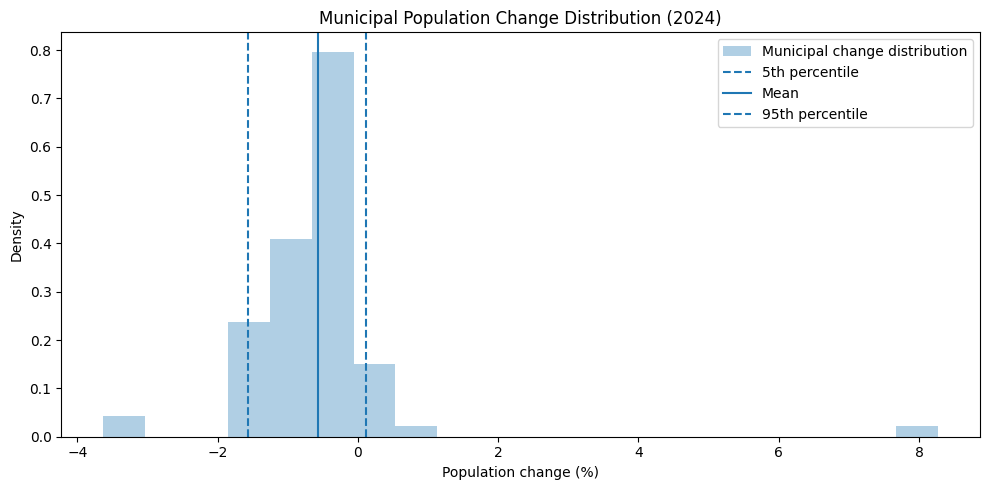

Saved: phase6_island_px_distribution.png


/var/folders/05/ctjbc6n50_xcbslxp158gts40000gn/T/ipykernel_35307/3017207031.py:190: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,year,total_population,weighted_avg_change_pct_3y,simple_avg_change_pct_3y,n_municipios
0,2013,3682966.0,-1.413606,-1.244873,78.0
1,2014,3638965.0,-1.585997,-1.448588,78.0
2,2015,3583073.0,-1.862079,-1.757983,78.0
3,2016,3529385.0,-2.036734,-1.926558,78.0
4,2017,3468963.0,-2.097033,-1.969294,78.0
5,2018,3386941.0,-0.723066,-0.947173,78.0
6,2019,3318447.0,-0.451699,-0.749513,78.0
7,2020,3255642.0,-0.009048,-0.334782,78.0
8,2021,3311274.0,-0.782854,-0.772453,78.0


Saved: phase6_island_year_summary_3y.csv
Saved: phase6_island_year_summary_3y.json


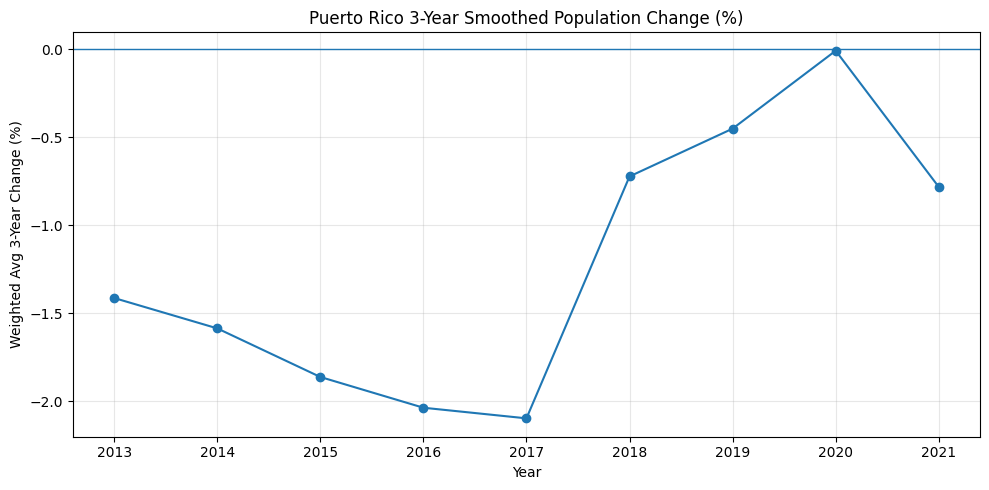

Saved: phase6_island_3y_change_trend.png


In [28]:
# --- Island-level trend charts + Px-style distribution chart ---
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

analysis_dir = Path(".")

def _normalize_municipio_name(s):
    return (
        str(s)
        .upper()
        .strip()
        .replace(" MUNICIPIO", "")
    )

# -------------------------------------------------------------------
# 1. Load processed panel data
# -------------------------------------------------------------------
processed_candidates = [
    analysis_dir / ".." / "data" / "processed_puerto_rico_data.csv",
    analysis_dir / "processed_puerto_rico_data.csv",
    analysis_dir / ".." / "analysis" / "processed_puerto_rico_data.csv",
]
processed_path = next((p for p in processed_candidates if p.exists()), None)

if processed_path is None:
    raise FileNotFoundError(
        "Could not find processed_puerto_rico_data.csv for island trend charts."
    )

panel_df = pd.read_csv(processed_path)

required_cols = ["municipio", "year"]
missing_required = [c for c in required_cols if c not in panel_df.columns]
if missing_required:
    raise ValueError(f"Missing required columns in processed panel: {missing_required}")

panel_df["mun_key"] = panel_df["municipio"].map(_normalize_municipio_name)
panel_df = panel_df.sort_values(["mun_key", "year"]).reset_index(drop=True)

# -------------------------------------------------------------------
# 2. Rebuild / identify fields
# -------------------------------------------------------------------
# Rebuild 3-year target if needed
if "target_pop_change_3y_avg" not in panel_df.columns and "target_pop_change" in panel_df.columns:
    grp = panel_df.groupby("mun_key")["target_pop_change"]
    panel_df["target_pop_change_3y_avg"] = (
        grp.shift(-1) + grp.shift(-2) + grp.shift(-3)
    ) / 3.0

# Choose a population level column
population_col = None
for candidate in ["total_population", "population", "population_level", "pop"]:
    if candidate in panel_df.columns and panel_df[candidate].notna().any():
        population_col = candidate
        break

if population_col is None:
    raise ValueError(
        "Could not find a usable population level column in processed_puerto_rico_data.csv."
    )

# -------------------------------------------------------------------
# 3. Build island-year summary (annual change as default)
# -------------------------------------------------------------------
if "target_pop_change" not in panel_df.columns:
    raise ValueError("Expected 'target_pop_change' in processed panel for annual trend chart.")

valid_annual = panel_df[[ "year", population_col, "target_pop_change"]].dropna().copy()
valid_annual = valid_annual[valid_annual[population_col] != 0].copy()

island_year_summary = (
    valid_annual.groupby("year")
    .apply(lambda x: pd.Series({
        "total_population": x[population_col].sum(),
        "weighted_avg_change_pct": (x[population_col] * x["target_pop_change"]).sum() / x[population_col].sum(),
        "simple_avg_change_pct": x["target_pop_change"].mean(),
        "n_municipios": len(x),
    }))
    .reset_index()
    .sort_values("year")
)

display(island_year_summary)

# Export yearly summary
island_year_summary_csv = analysis_dir / "phase6_island_year_summary.csv"
island_year_summary_json = analysis_dir / "phase6_island_year_summary.json"
island_year_summary.to_csv(island_year_summary_csv, index=False)
with open(island_year_summary_json, "w") as f:
    json.dump(island_year_summary.to_dict(orient="records"), f, indent=2)

print(f"Saved: {island_year_summary_csv}")
print(f"Saved: {island_year_summary_json}")

# -------------------------------------------------------------------
# 4. Option A: Line chart (population trend)
# -------------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(
    island_year_summary["year"],
    island_year_summary["total_population"],
    marker="o"
)
plt.title("Puerto Rico Total Population by Year")
plt.xlabel("Year")
plt.ylabel("Total Population")
plt.grid(alpha=0.3)
plt.tight_layout()

line_chart_path = analysis_dir / "phase6_island_population_trend.png"
plt.savefig(line_chart_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {line_chart_path}")

# -------------------------------------------------------------------
# 5. Option B: Bar chart (annual weighted % change)
# -------------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.bar(
    island_year_summary["year"].astype(str),
    island_year_summary["weighted_avg_change_pct"]
)
plt.axhline(0, linewidth=1)
plt.title("Puerto Rico Annual Population Change (%)")
plt.xlabel("Year")
plt.ylabel("Weighted Avg Change (%)")
plt.xticks(rotation=45)
plt.tight_layout()

bar_chart_path = analysis_dir / "phase6_island_annual_change_bar.png"
plt.savefig(bar_chart_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {bar_chart_path}")

# -------------------------------------------------------------------
# 6. Px-style distribution chart (municipal annual change distribution)
# -------------------------------------------------------------------
# Use latest year with non-null annual target
latest_valid_year = (
    panel_df.loc[panel_df["target_pop_change"].notna(), "year"]
    .max()
)

dist_df = panel_df.loc[
    (panel_df["year"] == latest_valid_year) &
    (panel_df["target_pop_change"].notna()),
    ["municipio", "target_pop_change"]
].copy()

if dist_df.empty:
    raise ValueError("No valid target_pop_change values found for Px distribution chart.")

vals = dist_df["target_pop_change"].to_numpy(dtype=float)
p5 = np.percentile(vals, 5)
p50 = np.percentile(vals, 50)
p95 = np.percentile(vals, 95)
mean_val = vals.mean()

plt.figure(figsize=(10, 5))
plt.hist(vals, bins=20, density=True, alpha=0.35, label="Municipal change distribution")
plt.axvline(p5, linestyle="--", linewidth=1.5, label="5th percentile")
plt.axvline(mean_val, linewidth=1.5, label="Mean")
plt.axvline(p95, linestyle="--", linewidth=1.5, label="95th percentile")
plt.title(f"Municipal Population Change Distribution ({latest_valid_year})")
plt.xlabel("Population change (%)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()

px_chart_path = analysis_dir / "phase6_island_px_distribution.png"
plt.savefig(px_chart_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {px_chart_path}")

# -------------------------------------------------------------------
# 7. Optional: 3-year smoothed island trend if available
# -------------------------------------------------------------------
if "target_pop_change_3y_avg" in panel_df.columns and panel_df["target_pop_change_3y_avg"].notna().any():
    valid_3y = panel_df[["year", population_col, "target_pop_change_3y_avg"]].dropna().copy()
    valid_3y = valid_3y[valid_3y[population_col] != 0].copy()

    island_year_summary_3y = (
        valid_3y.groupby("year")
        .apply(lambda x: pd.Series({
            "total_population": x[population_col].sum(),
            "weighted_avg_change_pct_3y": (x[population_col] * x["target_pop_change_3y_avg"]).sum() / x[population_col].sum(),
            "simple_avg_change_pct_3y": x["target_pop_change_3y_avg"].mean(),
            "n_municipios": len(x),
        }))
        .reset_index()
        .sort_values("year")
    )

    display(island_year_summary_3y)

    island_year_summary_3y_csv = analysis_dir / "phase6_island_year_summary_3y.csv"
    island_year_summary_3y_json = analysis_dir / "phase6_island_year_summary_3y.json"
    island_year_summary_3y.to_csv(island_year_summary_3y_csv, index=False)
    with open(island_year_summary_3y_json, "w") as f:
        json.dump(island_year_summary_3y.to_dict(orient="records"), f, indent=2)

    print(f"Saved: {island_year_summary_3y_csv}")
    print(f"Saved: {island_year_summary_3y_json}")

    plt.figure(figsize=(10, 5))
    plt.plot(
        island_year_summary_3y["year"],
        island_year_summary_3y["weighted_avg_change_pct_3y"],
        marker="o"
    )
    plt.axhline(0, linewidth=1)
    plt.title("Puerto Rico 3-Year Smoothed Population Change (%)")
    plt.xlabel("Year")
    plt.ylabel("Weighted Avg 3-Year Change (%)")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    line_chart_3y_path = analysis_dir / "phase6_island_3y_change_trend.png"
    plt.savefig(line_chart_3y_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved: {line_chart_3y_path}")
else:
    print("No usable target_pop_change_3y_avg values available for 3-year trend chart.")

In [29]:
from pathlib import Path
import pandas as pd

analysis_dir = Path(".")

forecast_candidates = [
    analysis_dir / "population_forecast.csv",
    analysis_dir / ".." / "analysis" / "population_forecast.csv",
    analysis_dir / ".." / "population_forecast.csv",
]
forecast_path = next((p for p in forecast_candidates if p.exists()), None)

if forecast_path is None:
    raise FileNotFoundError("Could not find population_forecast.csv")

forecast_df = pd.read_csv(forecast_path)

print("Loaded:", forecast_path)
print("Shape:", forecast_df.shape)
print("Columns:")
print(list(forecast_df.columns))
display(forecast_df.head())

Loaded: population_forecast.csv
Shape: (6, 7)
Columns:
['year', 'expected', 'lower_band', 'upper_band', 'adverse_change_rate', 'expected_change_rate', 'favorable_change_rate']


,year,expected,lower_band,upper_band,adverse_change_rate,expected_change_rate,favorable_change_rate
0,2025,3191995,3153697,3217911,-0.024924,-0.013083,-0.00507
1,2026,3150235,3075095,3201597,-0.024924,-0.013083,-0.00507
2,2027,3109021,2998451,3185365,-0.024924,-0.013083,-0.00507
3,2028,3068347,2923718,3169215,-0.024924,-0.013083,-0.00507
4,2029,3028204,2850848,3153148,-0.024924,-0.013083,-0.00507


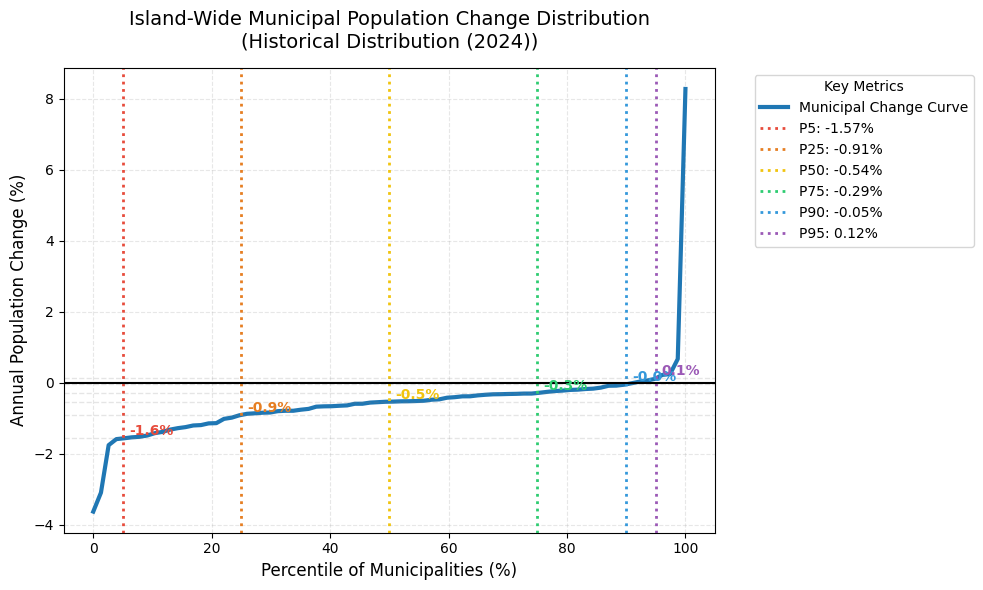


--- Percentile Summary: Historical Distribution (2024) ---
P5   :  -1.57%
P25  :  -0.91%
P50  :  -0.54%
P75  :  -0.29%
P90  :  -0.05%
P95  :   0.12%
Mean :  -0.57%


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==========================================
# 1. AUTO-LOAD DATA (Avoids NameError)
# ==========================================
analysis_dir = Path(".")
# List of paths where your processed data might be
processed_path = next((p for p in [
    analysis_dir / "processed_puerto_rico_data.csv",
    analysis_dir / ".." / "data" / "processed_puerto_rico_data.csv",
    analysis_dir / ".." / "analysis" / "processed_puerto_rico_data.csv"
] if p.exists()), None)

if processed_path:
    # Load and find the latest historical data
    panel_df = pd.read_csv(processed_path)
    latest_year = panel_df.loc[panel_df["target_pop_change"].notna(), "year"].max()
    vals = panel_df.loc[
        (panel_df["year"] == latest_year) & (panel_df["target_pop_change"].notna()), 
        "target_pop_change"
    ].to_numpy(dtype=float)
    chart_label = f"Historical Distribution ({int(latest_year)})"
else:
    # Fallback to current memory if file isn't found
    if 'dist_df' in locals():
        vals = dist_df["target_pop_change"].dropna().to_numpy(dtype=float)
        chart_label = "Historical Distribution"
    elif 'forecast_df' in locals() and 'expected' in forecast_df.columns:
        # NOTE: Using island-level forecast only provides 1 point. 
        # If you want the municipal-level forecast distribution, 
        # ensure you have the municipal prediction table loaded.
        vals = forecast_df["expected"].dropna().to_numpy(dtype=float)
        chart_label = "2030 Forecast Distribution"
    else:
        raise FileNotFoundError("Data not found. Please run Cells 46 & 47 or ensure the CSV files are in your directory.")

# ==========================================
# 2. CALCULATE PERCENTILES & PLOT
# ==========================================
percentile_levels = [5, 25, 50, 75, 90, 95]
percentile_values = np.percentile(vals, percentile_levels)
px_dict = dict(zip(percentile_levels, percentile_values))

plt.figure(figsize=(10, 6))
sorted_vals = np.sort(vals)
percentiles = np.linspace(0, 100, len(sorted_vals))

# Plot the main curve
plt.plot(percentiles, sorted_vals, color='#1f77b4', linewidth=3, label='Municipal Change Curve')

# Add vertical and horizontal lines for key Px values
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6']
for i, (p, val) in enumerate(px_dict.items()):
    plt.axhline(val, color='gray', linestyle='--', alpha=0.2, linewidth=1)
    plt.axvline(p, color=colors[i % len(colors)], linestyle=':', linewidth=2, label=f'P{p}: {val:.2f}%')
    plt.text(p + 1, val, f'{val:.1f}%', va='bottom', fontweight='bold', color=colors[i % len(colors)])

# Formatting
plt.title(f'Island-Wide Municipal Population Change Distribution\n({chart_label})', fontsize=14, pad=15)
plt.xlabel('Percentile of Municipalities (%)', fontsize=12)
plt.ylabel('Annual Population Change (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.axhline(0, color='black', linewidth=1.5) 

plt.legend(title="Key Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print summary table
print(f"\n--- Percentile Summary: {chart_label} ---")
for p, v in px_dict.items():
    print(f"P{p:<3} : {v:>6.2f}%")
print(f"Mean : {vals.mean():>6.2f}%")

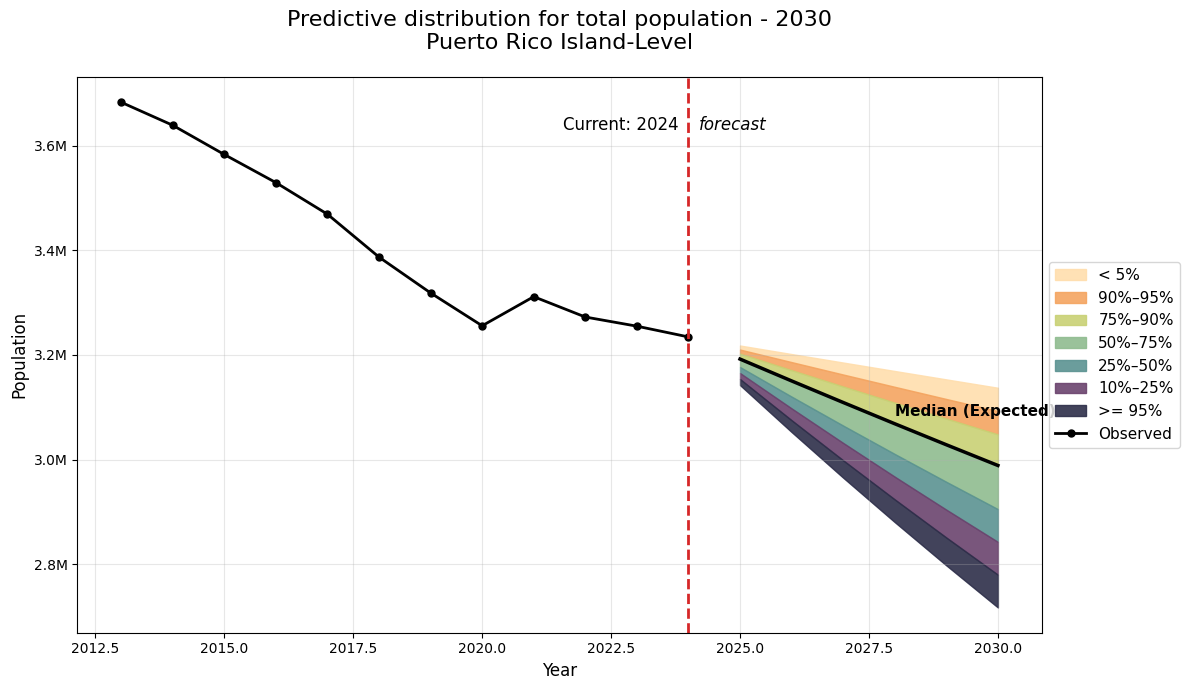

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib.ticker import FuncFormatter

# ==========================================
# 1. AUTO-LOAD DATA (Avoids NameError)
# ==========================================
analysis_dir = Path(".")

# Load Historical Data
if 'hist_island' in locals() and 'observed_population' in hist_island.columns:
    hist_df = hist_island.copy()
elif 'island_year_summary' in locals() and 'total_population' in island_year_summary.columns:
    hist_df = island_year_summary.copy()
    hist_df = hist_df.rename(columns={'total_population': 'observed_population'})
else:
    hist_path = analysis_dir / "phase6_island_year_summary.csv"
    if hist_path.exists():
        hist_df = pd.read_csv(hist_path)
        hist_df = hist_df.rename(columns={'total_population': 'observed_population'})
    else:
        raise FileNotFoundError("Could not find historical data. Please run the cell that creates 'island_year_summary' first.")

# Load Forecast Data
if 'forecast_df' in locals() and 'expected' in forecast_df.columns:
    f_df = forecast_df.copy()
else:
    forecast_path = next((p for p in [
        analysis_dir / "population_forecast.csv",
        analysis_dir / ".." / "analysis" / "population_forecast.csv",
        analysis_dir / ".." / "population_forecast.csv"
    ] if p.exists()), None)
    
    if forecast_path:
        f_df = pd.read_csv(forecast_path)
    else:
        raise FileNotFoundError("Could not find population_forecast.csv. Please run Cell 47 or check your file paths.")

# Clean up years
hist_df['year'] = hist_df['year'].astype(int)
f_df['year'] = f_df['year'].astype(int)

# ==========================================
# 2. CALCULATE BANDS AND PLOT
# ==========================================
colors = {
    '95plus': '#2d2e49', # Dark Purple
    '90_95_lower': '#6b436e', # Mid Purple
    '75_90_lower': '#5b9391', # Teal
    '50_75_lower': '#8fbc8f', # Soft Green
    '50_75_upper': '#c9d175', # Yellow-Green
    '75_90_upper': '#f4a460', # Orange
    '90_95_upper': '#ffdead', # Light Orange
}

plt.figure(figsize=(12, 7), facecolor='white')
ax = plt.gca()

# Calculate intermediate bands
spread_lower = f_df['expected'] - f_df['lower_band']
spread_upper = f_df['upper_band'] - f_df['expected']

f_df['p25'] = f_df['expected'] - (spread_lower * 0.4)
f_df['p75'] = f_df['expected'] + (spread_upper * 0.4)
f_df['p10'] = f_df['expected'] - (spread_lower * 0.7)
f_df['p90'] = f_df['expected'] + (spread_upper * 0.7)

# Draw Upper bands
plt.fill_between(f_df['year'], f_df['p90'], f_df['upper_band'], color=colors['90_95_upper'], label='< 5%', alpha=0.9)
plt.fill_between(f_df['year'], f_df['p75'], f_df['p90'], color=colors['75_90_upper'], label='90%–95%', alpha=0.9)
plt.fill_between(f_df['year'], f_df['p75'], f_df['expected'], color=colors['50_75_upper'], label='75%–90%', alpha=0.9)

# Draw Lower bands
plt.fill_between(f_df['year'], f_df['expected'], f_df['p25'], color=colors['50_75_lower'], label='50%–75%', alpha=0.9)
plt.fill_between(f_df['year'], f_df['p25'], f_df['p10'], color=colors['75_90_lower'], label='25%–50%', alpha=0.9)
plt.fill_between(f_df['year'], f_df['p10'], f_df['lower_band'], color=colors['90_95_lower'], label='10%–25%', alpha=0.9)
plt.fill_between(f_df['year'], f_df['lower_band'], f_df['lower_band'] - (spread_lower * 0.3), color=colors['95plus'], label='>= 95%', alpha=0.9)

# Plot Historical Data Line
plt.plot(hist_df['year'], hist_df['observed_population'], color='black', marker='o', 
         markersize=5, linewidth=2, label='Observed')

# Plot Median Forecast Line
plt.plot(f_df['year'], f_df['expected'], color='black', linewidth=2.5)

# Add Labels and Lines
target_year = min(2028, f_df['year'].max())
expected_val = f_df.loc[f_df['year'] == target_year, 'expected'].values[0]
plt.text(target_year, expected_val + 15000, "Median (Expected)", fontsize=11, fontweight='bold')

current_year = int(hist_df['year'].max())
plt.axvline(x=current_year, color='#d62728', linestyle='--', linewidth=2)
plt.text(current_year - 0.2, ax.get_ylim()[1] * 0.98, f'Current: {current_year}', ha='right', va='top', fontsize=12)
plt.text(current_year + 0.2, ax.get_ylim()[1] * 0.98, 'forecast', ha='left', va='top', fontsize=12, style='italic')

# Formatting
plt.title('Predictive distribution for total population - 2030\nPuerto Rico Island-Level', fontsize=16, pad=20)
plt.ylabel('Population', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.grid(True, which='both', linestyle='-', alpha=0.3)

# Format Y-axis (e.g., 3.2M)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=11)
plt.tight_layout()

# Save and Show
plt.savefig('island_fan_chart_final.png', dpi=300)
plt.show()